# Earthquake Damage Prediction

  ## Problem statement: Create a predictive model  to predict the levle of damage grade affected by earthquake"

In [1]:
# Importing all the basic libararies
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Loading the dataset
train_values=pd.read_csv('E:\\EquakeDamagePred\\Data\\train_values.csv')
train_labels=pd.read_csv('E:\\EquakeDamagePred\\Data\\train_labels.csv')

In [5]:
# Merging the value and labels
data=train_values.merge(train_labels, on='building_id')

## Basic checks

In [11]:
data.head()

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,...,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
0,802906,6,487,12198,2,30,6,5,t,r,...,0,0,0,0,0,0,0,0,0,3
1,28830,8,900,2812,2,10,8,7,o,r,...,0,0,0,0,0,0,0,0,0,2
2,94947,21,363,8973,2,10,5,5,t,r,...,0,0,0,0,0,0,0,0,0,3
3,590882,22,418,10694,2,10,6,5,t,r,...,0,0,0,0,0,0,0,0,0,2
4,201944,11,131,1488,3,30,8,9,t,r,...,0,0,0,0,0,0,0,0,0,3


In [6]:
data.tail()

,building_id,damage_grade,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,...,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other
260596,688636,2,25,1335,1621,1,55,6,3,n,...,0,0,0,0,0,0,0,0,0,0
260597,669485,3,17,715,2060,2,0,6,5,t,...,0,0,0,0,0,0,0,0,0,0
260598,602512,3,17,51,8163,3,55,6,7,t,...,0,0,0,0,0,0,0,0,0,0
260599,151409,2,26,39,1851,2,10,14,6,t,...,0,0,0,0,0,0,0,0,0,0
260600,747594,3,21,9,9101,3,10,7,6,n,...,0,0,0,0,0,0,0,0,0,0


In [7]:
data.shape

(260601, 40)

In [10]:
data.columns

Index(['building_id', 'damage_grade', 'geo_level_1_id', 'geo_level_2_id',
       'geo_level_3_id', 'count_floors_pre_eq', 'age', 'area_percentage',
       'height_percentage', 'land_surface_condition', 'foundation_type',
       'roof_type', 'ground_floor_type', 'other_floor_type', 'position',
       'plan_configuration', 'has_superstructure_adobe_mud',
       'has_superstructure_mud_mortar_stone', 'has_superstructure_stone_flag',
       'has_superstructure_cement_mortar_stone',
       'has_superstructure_mud_mortar_brick',
       'has_superstructure_cement_mortar_brick', 'has_superstructure_timber',
       'has_superstructure_bamboo', 'has_superstructure_rc_non_engineered',
       'has_superstructure_rc_engineered', 'has_superstructure_other',
       'legal_ownership_status', 'count_families', 'has_secondary_use',
       'has_secondary_use_agriculture', 'has_secondary_use_hotel',
       'has_secondary_use_rental', 'has_secondary_use_institution',
       'has_secondary_use_school', 'has

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260601 entries, 0 to 260600
Data columns (total 40 columns):
 #   Column                                  Non-Null Count   Dtype 
---  ------                                  --------------   ----- 
 0   building_id                             260601 non-null  int64 
 1   damage_grade                            260601 non-null  int64 
 2   geo_level_1_id                          260601 non-null  int64 
 3   geo_level_2_id                          260601 non-null  int64 
 4   geo_level_3_id                          260601 non-null  int64 
 5   count_floors_pre_eq                     260601 non-null  int64 
 6   age                                     260601 non-null  int64 
 7   area_percentage                         260601 non-null  int64 
 8   height_percentage                       260601 non-null  int64 
 9   land_surface_condition                  260601 non-null  object
 10  foundation_type                         260601 non-null 

In [85]:
# Statistical summary
print("Statistical Summary of Numerical Features:")
data.describe().T

Statistical Summary of Numerical Features:


,count,mean,std,min,25%,50%,75%,max
building_id,260601.0,525675.482773,304544.999032,4.0,261190.0,525757.0,789762.0,1052934.0
geo_level_1_id,260601.0,13.900353,8.033617,0.0,7.0,12.0,21.0,30.0
geo_level_2_id,260601.0,701.074685,412.710734,0.0,350.0,702.0,1050.0,1427.0
geo_level_3_id,260601.0,6257.876148,3646.369645,0.0,3073.0,6270.0,9412.0,12567.0
count_floors_pre_eq,260601.0,2.129723,0.727665,1.0,2.0,2.0,2.0,9.0
age,260601.0,26.535029,73.565937,0.0,10.0,15.0,30.0,995.0
area_percentage,260601.0,8.018051,4.392231,1.0,5.0,7.0,9.0,100.0
height_percentage,260601.0,5.434365,1.918418,2.0,4.0,5.0,6.0,32.0
has_superstructure_adobe_mud,260601.0,0.088645,0.284231,0.0,0.0,0.0,0.0,1.0
has_superstructure_mud_mortar_stone,260601.0,0.761935,0.425900,0.0,1.0,1.0,1.0,1.0


In [18]:
# Checking null values
data.isnull().sum()

building_id                               0
damage_grade                              0
geo_level_1_id                            0
geo_level_2_id                            0
geo_level_3_id                            0
count_floors_pre_eq                       0
age                                       0
area_percentage                           0
height_percentage                         0
land_surface_condition                    0
foundation_type                           0
roof_type                                 0
ground_floor_type                         0
other_floor_type                          0
position                                  0
plan_configuration                        0
has_superstructure_adobe_mud              0
has_superstructure_mud_mortar_stone       0
has_superstructure_stone_flag             0
has_superstructure_cement_mortar_stone    0
has_superstructure_mud_mortar_brick       0
has_superstructure_cement_mortar_brick    0
has_superstructure_timber       

In [11]:
# Checking duplicate values
data.duplicated().sum()

np.int64(0)

# Domain analysis

* damage_grade(Target Variable):-
    * Type: Ordinal categorical (1, 2, 3)
    * 1 → Low damage
      * Minor cracks in walls.
      * Plaster damage.
      * Non-structural elements affected.
      * Building is safe to occupy.
    
    * 2 → Medium damage
      * Large cracks in walls.
      *  Partial wall failure.
      *  Columns/beams cracked but standing.

    * 3 → Severe damage / collapse
      * Partial or full collapse.
      *  Pancaking floors.
      *  Foundation failure.
      *  Building is unsafe / destroyed.

Domain importance:
This is the prediction target. Building structure, material, age, height, and location heavily influence this.

Geographic Information
* Geographic Information means data that tells us where something is located on the Earth.

* geo_level_1_id:-
    * Level: Province / large region
    * Range: 0–30

* geo_level_2_id:-
    * Level: District / zone
    * Range: 0–1427

* geo_level_3_id:-
    * Level: Municipality / ward
    * Range: 0–12567

Domain significance:
* Earthquake intensity variation
* Soil type
* Construction practices
* Higher predictive power, especially geo_level_3

Building Geometry & Age

* count_floors_pre_eq:-
    * More numbers of floors more damage beacause Higher bending force,More load on columns,Higher chance of cracks or collapse.
    * Especially dangerous if Old buildings are Weak foundation and Non-engineered construction.
    * More floors → higher collapse risk

* age:-
    * Older buildings suffer more damage because old construction techniques,material degradation over time.
    * So the building becomes structurally weaker.
    * Older buildings → weaker materials & outdated codes.
    * Strong positive correlation with damage grade.

* area_percentage:-
    * Larger area is more damage because have more mass,carry more load,generate more inertia while shaking.
    * Risk increases if foundation is weak and columns are evenly distributed.
    * Larger area is heavier load = more damage risk.

* height_percentage:-
    * High height relative to area may indicate slender buildings, which can be more sensitive to higher‑mode effects and torsional response.
    * Height matters even more when Plan is irregular,Materials are weak,Soil is soft.
    * Higher height_percentage is stronger motion = higher damage.

Land & Ground Characteristics
* land_surface_condition:-
    * Land Surface Condition Matters because of Earthquake energy travels through the ground first.
    * Sloped or uneven land increases instability during EQ.
    * Condition of the land surface (values: n, o, t).
    * n – Normal (Flat Land), o – Other (Uneven / Mild Slope), t – Terraced (Steep / Stepped Land)

* foundation_type:-
    * foundation type is very important because Whole building depends on foundation strength.
    *  If foundation is strong then less damage.
    * if Mud-based foundations then it high collapse chances.
    * Type of foundation (values: h, i, r, u, w)
    * h – Mud Mortar with Stone / Brick, i – Reinforced Concrete (RCC) Foundation, r – Rubble Stone Foundation, u – Mud Mortar Foundation, w – Wooden Foundation.

Structural Components
* roof_type:-
    * roof type matters in earthquakes because of During an earthquake The roof acts like a load on top of the building.
    * Buildings with heavy roof materials experience higher seismic forces, increasing the risk of collapse and severe damage.
    * Type of roof(values: n, q, x)
    * n – Mud / Clay / Thatch Roof, q – CGI / Metal Sheet Roof, x – RCC / Concrete Slab Roof.

* ground_floor_type:-
    * The ground floor Receives earthquake force first,Supports the entire building above.
    * If the ground floor is weak It cannot resist lateral shaking,Upper floors push down on it,Ground floor fails suddenly.
    * Type of ground floor(values: m, f, v, z, x )
    * m – Mud Ground Floor, f – Brick / Stone Masonry Ground Floor, v – RCC Ground Floor (Best), z – Wooden Ground Floor, x – Other / Mixed Ground Floor.

* other_floor_type:-
    * If upper floors are weak They crack easily,Add uneven load,Increase stress on columns.
    * Poor upper floor materials (mud, stone, weak timber) Cannot handle vibration,Fail under repeated shaking.
    * Poor-quality upper floor materials increase structural stress during earthquakes, contributing to higher damage grades.
    * Type of other floor(values: j, s, q, x)
    * j – Mud / Weak Masonry Upper Floors, s – Stone / Brick Masonry Upper Floors, q – Light Metal / Timber Upper Floors, x – RCC / Engineered Upper Floors.

Building Position & Layout
* position:-
    * During an earthquake, buildings move and shake.
    * If buildings are connected, they affect each other’s movement.
    * Corner buildings often experience higher torsion; isolated buildings may be less affected by pounding.
    * Relative position of the building (values: j, o, s, t).
    * j – Joined on Both Sides, s – Semi-attached (One Side), o – Open / Isolated, t – Dense Block / Clustered

* plan_configuration:-
    * It describes the shape of the building when viewed from the top (floor plan).
    * Irregular shapes perform poorly during earthquakes.
    * Complex shapes create twisting and stress.
    * Relative position of the plan_configuration(values: a, c, d, f, m, n, o, q, s, u).
    * a	- Rectangular, c - Square plan, d - L-shaped plan, f	- U-shaped plan, m - Multiple units, n - Narrow / elongated plan, o - T-shaped plan,
      q - Cross / plus shaped, s - Stepped / split, u - Complex / unspecified irregular.
    * Regular plans (a, c), Moderately irregular plans (n, d, s, m), Highly irregular plans (f, o, q, u).

Superstructure Materials

 Each column indicates presence (1) or absence (0).
* has_superstructure_adobe_mud, has_superstructure_mud_mortar_stone,  has_superstructure_mud_mortar_brick :-
    * These are weak materials(High risk).
    * Very high vulnerability: low strength, brittle behavior, poor ductility, and common in rural areas.
    * These materials are strongly associated with collapse in low‑ and medium‑rise buildings.

* has_superstructure_stone_flag, has_superstructure_cement_mortar_stone,  has_superstructure_cement_mortar_brick :-
    * Rubble stone is weak and irregular; cement‑mortared stone improves performance but still lacks ductility.
    * Separate into “poor stone” (rubble) vs. “better stone” (cement‑mortared).
    * Compare their damage profiles with roof_type (heavy roof on stone = high risk).
    * Cement‑mortared brick → moderate damage (better than mud, worse than engineered RC).

* has_superstructure_timber:-
    * The main load-bearing structure of the building is made using timber (wood).
    * In many cases, timber performs better than brick or stone masonry.
    * Timber buildings survive earthquakes not because they are strong, but because they are flexible.

*  has_superstructure_bamboo:-
    * bamboo is used as a primary structural material.
    * Despite being “weak” material, bamboo performs surprisingly well.

* has_superstructure_rc_non_engineered:-
    * Non‑engineered RC (poor detailing, lack of ductile detailing) → medium–high damage.
    * RC without engineering can be more dangerous than lightweight traditional materials.

* has_superstructure_rc_engineered:-
    * Engineered RC (proper detailing, seismic design) → lowest damage.
    * Typically newer, urban, regulated construction.

* has_superstructure_other:-
    * Rare or unusual materials.
    * Often unpredictable damage behavior.

Ownership & Occupancy
* legal_ownership_status:-
    * Strong property rights (e.g., private ownership) are associated with better maintenance and willingness to invest in quality construction.
    * It indirectly reflects Construction quality Compliance with building codes Access to permits, loans, and inspections.
    * Land ownership (values: a, r, v, w).
    * v – Informal / Unregistered, w – Other / Unknown, r – Private / Registered, a – Institutional / Government.

* count_families:-
    * High number often indicates multi‑family, low‑income, or overcrowded buildings, which may be hastily constructed or over‑topped.
    * These buildings may have higher social and economic impact when damaged.

Secondary Usage
* has_secondary_use:-
    * This feature indicates whether a building is used for more than just residential purposes.
* has_secondary_use_agriculture:-
    * Used for storing crops, tools, livestock.Slight increase in damage risk.
* has_secondary_use_hotel:-
    * Building is used as a hotel or lodge. 
    * Higher occupancy,Interior modifications,Heavier live loads.Mostly damage_grade = 2.
* has_secondary_use_rental:-
    * Building is used for renting rooms or houses.
    * Partitioned rooms,Altered load paths,Unplanned extensions.Higher chance of moderate to severe damage.
* has_secondary_use_institution:-
    * Building used for offices, NGOs, training centers, or institutions.
    * Planned construction so Better safety standards.
* has_secondary_use_school:-
    * Building used as a school. 
    * Larger halls, fewer walls,Increased span lengths.Vulnerable if not engineered.
    * Built with safety regulations also Wider columns and beams.
* has_secondary_use_industry:-
    * Building used for industrial activities. 
    * Heavy machinery,Increased vibration + load.Higher risk of damage_grade = 3.
* has_secondary_use_health_post:-
    * Building used as a health center or clinic. 
    * Equipment loads,Functional importance,Often built stronger, but older ones suffer.Mostly damage_grade = 2.
* has_secondary_use_gov_office:-
    * Building used as a government office. 
    * Better construction standards,Planned layouts.Usually less severe damage.
* has_secondary_use_use_police:-
    * Building used as a police station. 
    * Similar to government buildings,Often RCC structures.Lower damage probability.
* has_secondary_use_other:- 
    * Any use not listed above,Behavior varies.Mixed damage pattern.

# Task 1: Data Analysis report (EDA)

## Univariate Analysis

In [87]:
# Copying the data
df_eda = data.copy()

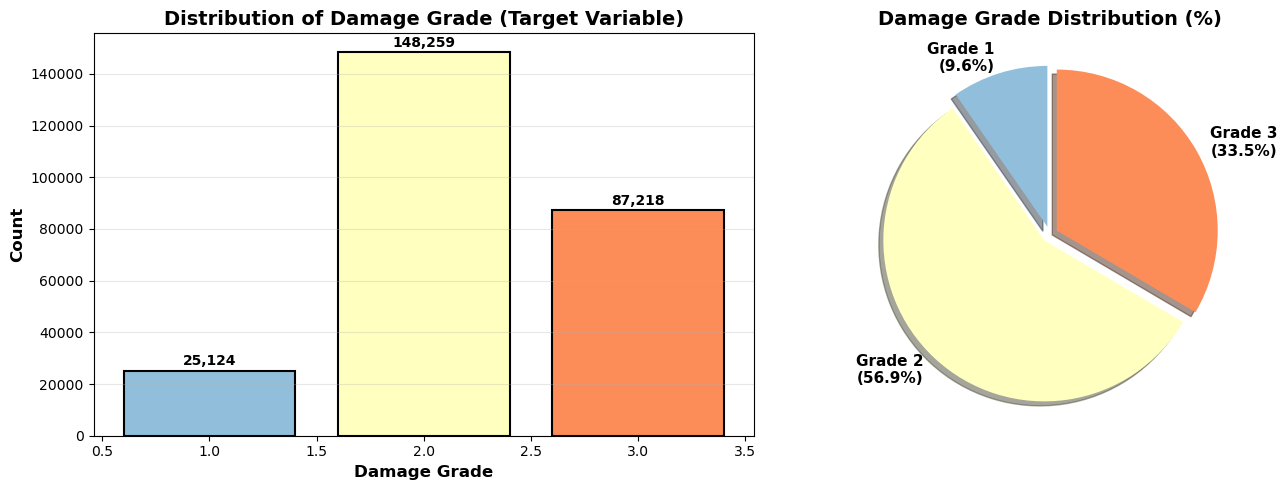

In [111]:
# Calulating each damage count and percentage for visualization of target variable
damage_counts = df_eda['damage_grade'].value_counts().sort_index()
damage_pct = (damage_counts / len(df) * 100)

# Visualize target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
axes[0].bar(damage_counts.index, damage_counts.values, color=['#91bfdb', '#ffffbf', '#fc8d59'], # Color-blind frindly colors
            edgecolor='black', linewidth=1.5)
axes[0].set_xlabel('Damage Grade', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=12, fontweight='bold')
axes[0].set_title('Distribution of Damage Grade (Target Variable)', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Add value labels
for i, v in enumerate(damage_counts.values):
    axes[0].text(i+1, v + 1000, f'{v:,}', ha='center', va='bottom', fontweight='bold')

# Percentage pie chart
colors = ['#91bfdb', '#ffffbf', '#fc8d59']
explode = (0.05, 0.05, 0.05)
axes[1].pie(damage_pct.values, 
            labels=[f'Grade {i}\n({v:.1f}%)' for i, v in zip(damage_pct.index, damage_pct.values)],
            autopct='', startangle=90, colors=colors, explode=explode,
            shadow=True, textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[1].set_title('Damage Grade Distribution (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

* The target variable is imbalanced.
* The majority of buildings sustained medium damage.
* The low representation of Grade 1 means our model might struggle to predict 'safe' buildings accurately unless we use techniques like SMOTE or Class Weights.

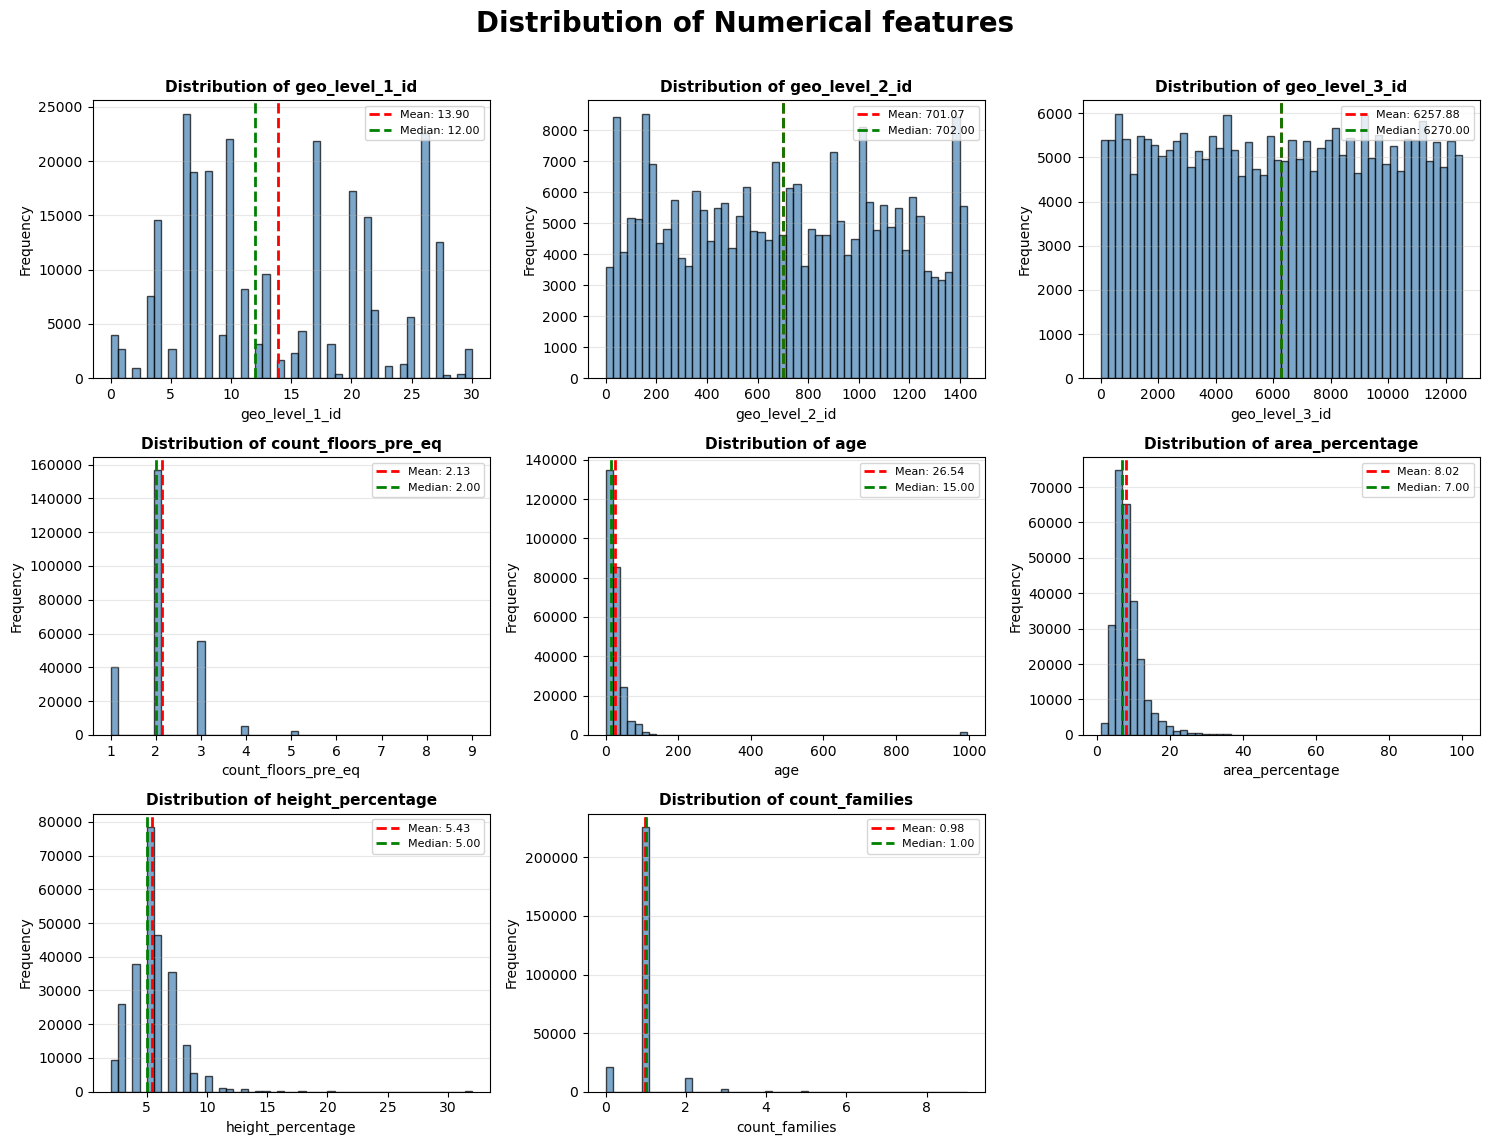

In [123]:
# Distribution of Numerical Features

# variable with numerical features of data
key_numerical = ['geo_level_1_id', 'geo_level_2_id', 'geo_level_3_id', 
                 'count_floors_pre_eq', 'age', 'area_percentage', 
                 'height_percentage', 'count_families']

# Plot distributions
n_cols = 3
n_rows = (len(key_numerical) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows*4))
axes = axes.flatten()

for idx, col in enumerate(key_numerical):
    # Histogram
    axes[idx].hist(df_eda[col].dropna(), bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribution of {col}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel(col, fontsize=10)
    axes[idx].set_ylabel('Frequency', fontsize=10)
    axes[idx].grid(axis='y', alpha=0.3)
    
    # Add mean and median lines
    mean_val = df_eda[col].mean()
    median_val = df_eda[col].median()
    axes[idx].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
    axes[idx].axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Median: {median_val:.2f}')
    axes[idx].legend(fontsize=8)

# Remove empty subplots
for idx in range(len(key_numerical), len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle('Distribution of Numerical features', fontsize=20,fontweight='bold', y=0.95)
# Adjust tight_layout to leave room at the top
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

In [99]:
# Statistical summary with skewness and kurtosis
stats_summary = pd.DataFrame()

for col in key_numerical:
    stats_summary.loc[col, 'Mean'] = df_eda[col].mean()
    stats_summary.loc[col, 'Median'] = df_eda[col].median()
    stats_summary.loc[col, 'Std'] = df_eda[col].std()
    stats_summary.loc[col, 'Skewness'] = df_eda[col].skew()
    stats_summary.loc[col, 'Kurtosis'] = df_eda[col].kurtosis()

print("\nStatistical Summary of Numerical Features:")
print("="*80)
display(stats_summary.style.background_gradient(cmap='RdYlGn_r', subset=['Skewness', 'Kurtosis']))

print("\n💡 Interpretation:")
print("   - Skewness > 1 or < -1: Highly skewed (consider log transformation)")
print("   - Kurtosis > 3: Heavy tails (more outliers than normal distribution)")


Statistical Summary of Numerical Features:


,Mean,Median,Std,Skewness,Kurtosis
geo_level_1_id,13.900353,12.000000,8.033617,0.272530,-1.213249
geo_level_2_id,701.074685,702.000000,412.710734,0.028957,-1.188232
geo_level_3_id,6257.876148,6270.000000,3646.369645,0.000394,-1.213897
count_floors_pre_eq,2.129723,2.000000,0.727665,0.834113,2.322598
age,26.535029,15.000000,73.565937,12.192494,157.248236
area_percentage,8.018051,7.000000,4.392231,3.526082,30.438258
height_percentage,5.434365,5.000000,1.918418,1.808262,14.318526
count_families,0.983949,1.000000,0.418389,1.634758,17.670943



💡 Interpretation:
   - Skewness > 1 or < -1: Highly skewed (consider log transformation)
   - Kurtosis > 3: Heavy tails (more outliers than normal distribution)


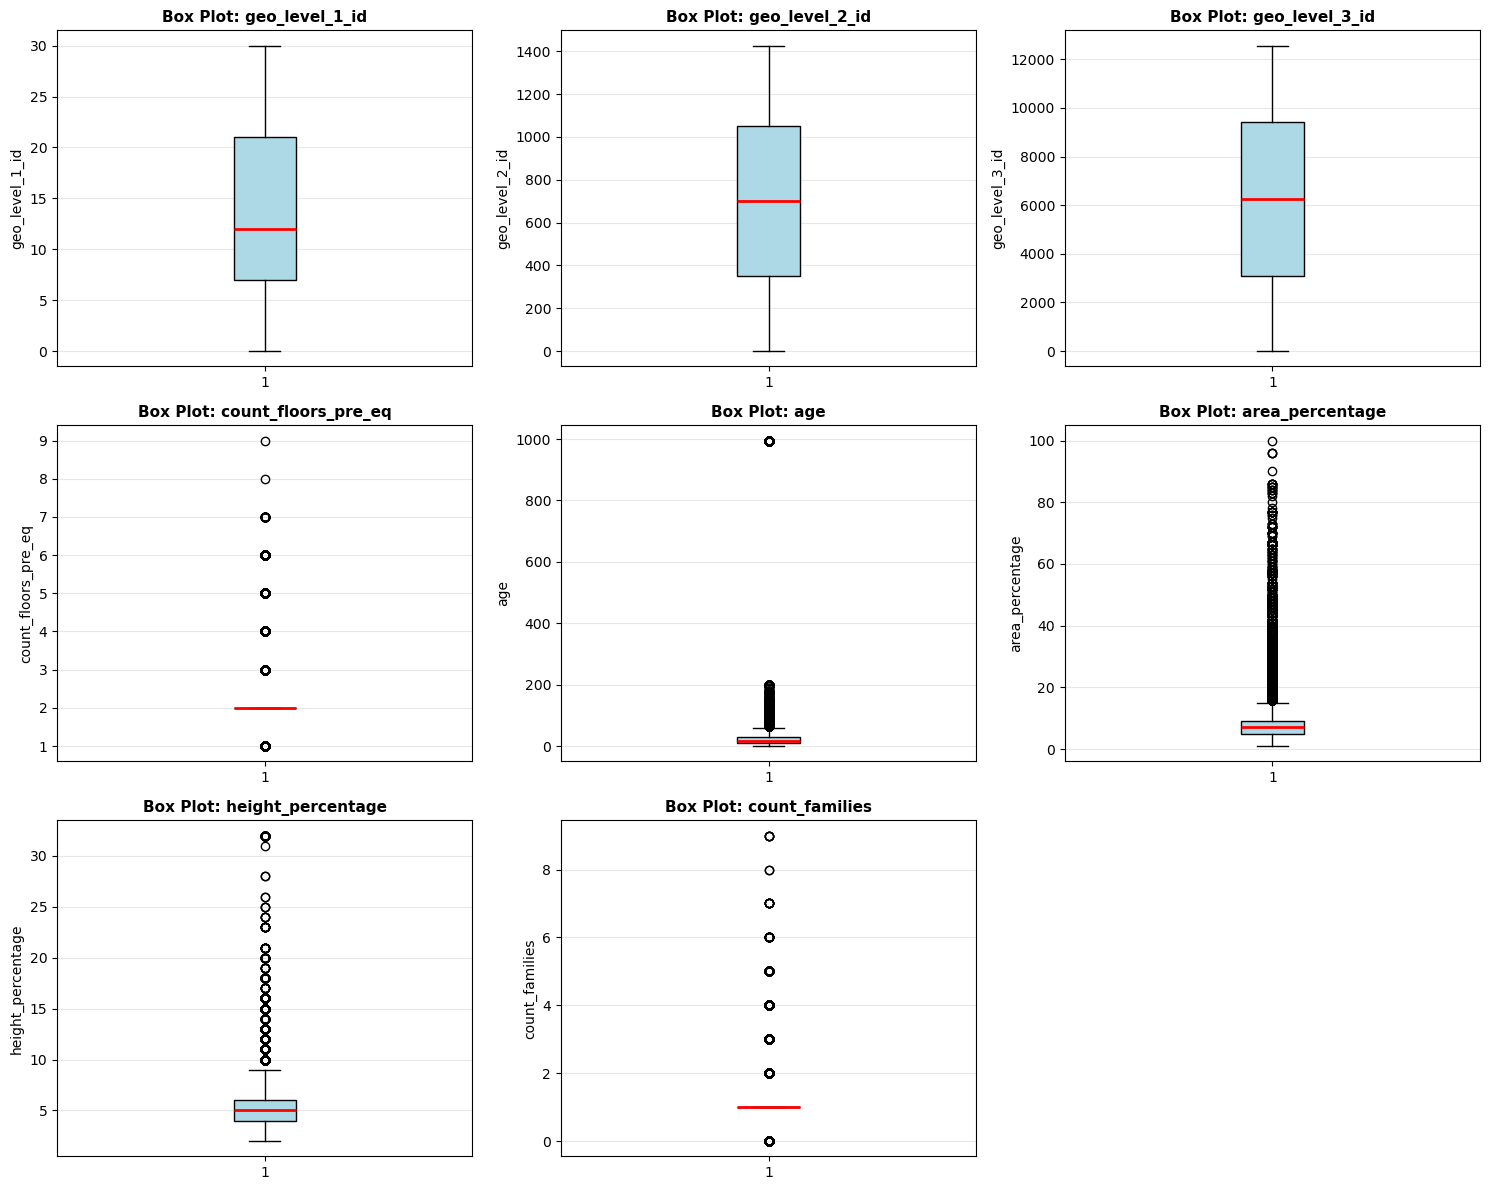

In [101]:
# Box plots
n_cols = 3
n_rows = (len(key_numerical) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows*4))
axes = axes.flatten()

for idx, col in enumerate(key_numerical):
    bp = axes[idx].boxplot(df_eda[col].dropna(), patch_artist=True, vert=True,
                           boxprops=dict(facecolor='lightblue', color='black'),
                           whiskerprops=dict(color='black'),
                           capprops=dict(color='black'),
                           medianprops=dict(color='red', linewidth=2))
    
    axes[idx].set_title(f'Box Plot: {col}', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel(col, fontsize=10)
    axes[idx].grid(axis='y', alpha=0.3)

for idx in range(len(key_numerical), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

In [103]:
# Calculate outliers using IQR method
outlier_summary = pd.DataFrame()

for col in key_numerical:
    Q1 = df_eda[col].quantile(0.25)
    Q3 = df_eda[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df_eda[(df_eda[col] < lower_bound) | (df_eda[col] > upper_bound)][col]
    outlier_summary.loc[col, 'Outlier_Count'] = len(outliers)
    outlier_summary.loc[col, 'Outlier_Percentage'] = (len(outliers) / len(df)) * 100
    outlier_summary.loc[col, 'Lower_Bound'] = lower_bound
    outlier_summary.loc[col, 'Upper_Bound'] = upper_bound

print("\nOutlier Detection Summary (IQR Method):")
print("="*80)
display(outlier_summary.style.background_gradient(cmap='Reds', subset=['Outlier_Percentage']))


Outlier Detection Summary (IQR Method):


,Outlier_Count,Outlier_Percentage,Lower_Bound,Upper_Bound
geo_level_1_id,0.000000,0.000000,-14.000000,42.000000
geo_level_2_id,0.000000,0.000000,-700.000000,2100.000000
geo_level_3_id,0.000000,0.000000,-6435.500000,18920.500000
count_floors_pre_eq,103978.000000,39.899310,2.000000,2.000000
age,12499.000000,4.796221,-20.000000,60.000000
area_percentage,13557.000000,5.202206,-1.000000,15.000000
height_percentage,7843.000000,3.009582,1.000000,9.000000
count_families,34486.000000,13.233257,1.000000,1.000000


As we can see from the graph above, all the plots for numerical features exhibit an excessive rightward skew. That means that there are a few observations for each variable which are much higher than the rest of the data. Another way to describe this phenomena would be to say that the mean of the distribution is higher than the median.

* `geo_level_1_id` is spatially clustered. Certain regions (e.g., ID 6) are over-represented in the dataset. If these regions happen to be near the earthquake epicenter, the model might bias towards predicting high damage for any building in that region.
* `geo_level_2_id` and `geo_level_3_id` reveals high-cardinality geographic clusters, where a small percentage of locations contain the majority of building records, necessitating Target Encoding to capture hyper-local seismic vulnerability without expanding feature dimensionality.
* The `age` distribution is right-skewed, indicating mostly new construction. However, there is a distinct spike at 995. In data collection, 995 often codes for 'Unknown' or 'Ancient.' We must treat this as a categorical anomaly, not a literal number.
* As for`count_floors_pre_eq`, the region is dominated by low-rise architecture (mostly 2-story). Tall buildings (>5 floors) are outliers. This suggests that vertical stress might not be the primary failure mode for the majority of the dataset.
* if we observe both `area_percentage` and `height_percentage`, most structures are small residential units. The positive skew indicates a few massive complexes (likely government or hotels). These large-area outliers might behave differently in an earthquake compared to small homes.
* `count_families` has low variance. Since almost every building houses exactly one family, this feature might not have strong predictive power on its own.

We will apply logarithmic transformation to compress the extreme right-skewness and high variance of numerical features like building age and area. This stabilizes the feature scales and prevents extreme outliers from disproportionately biasing the model's learning process.

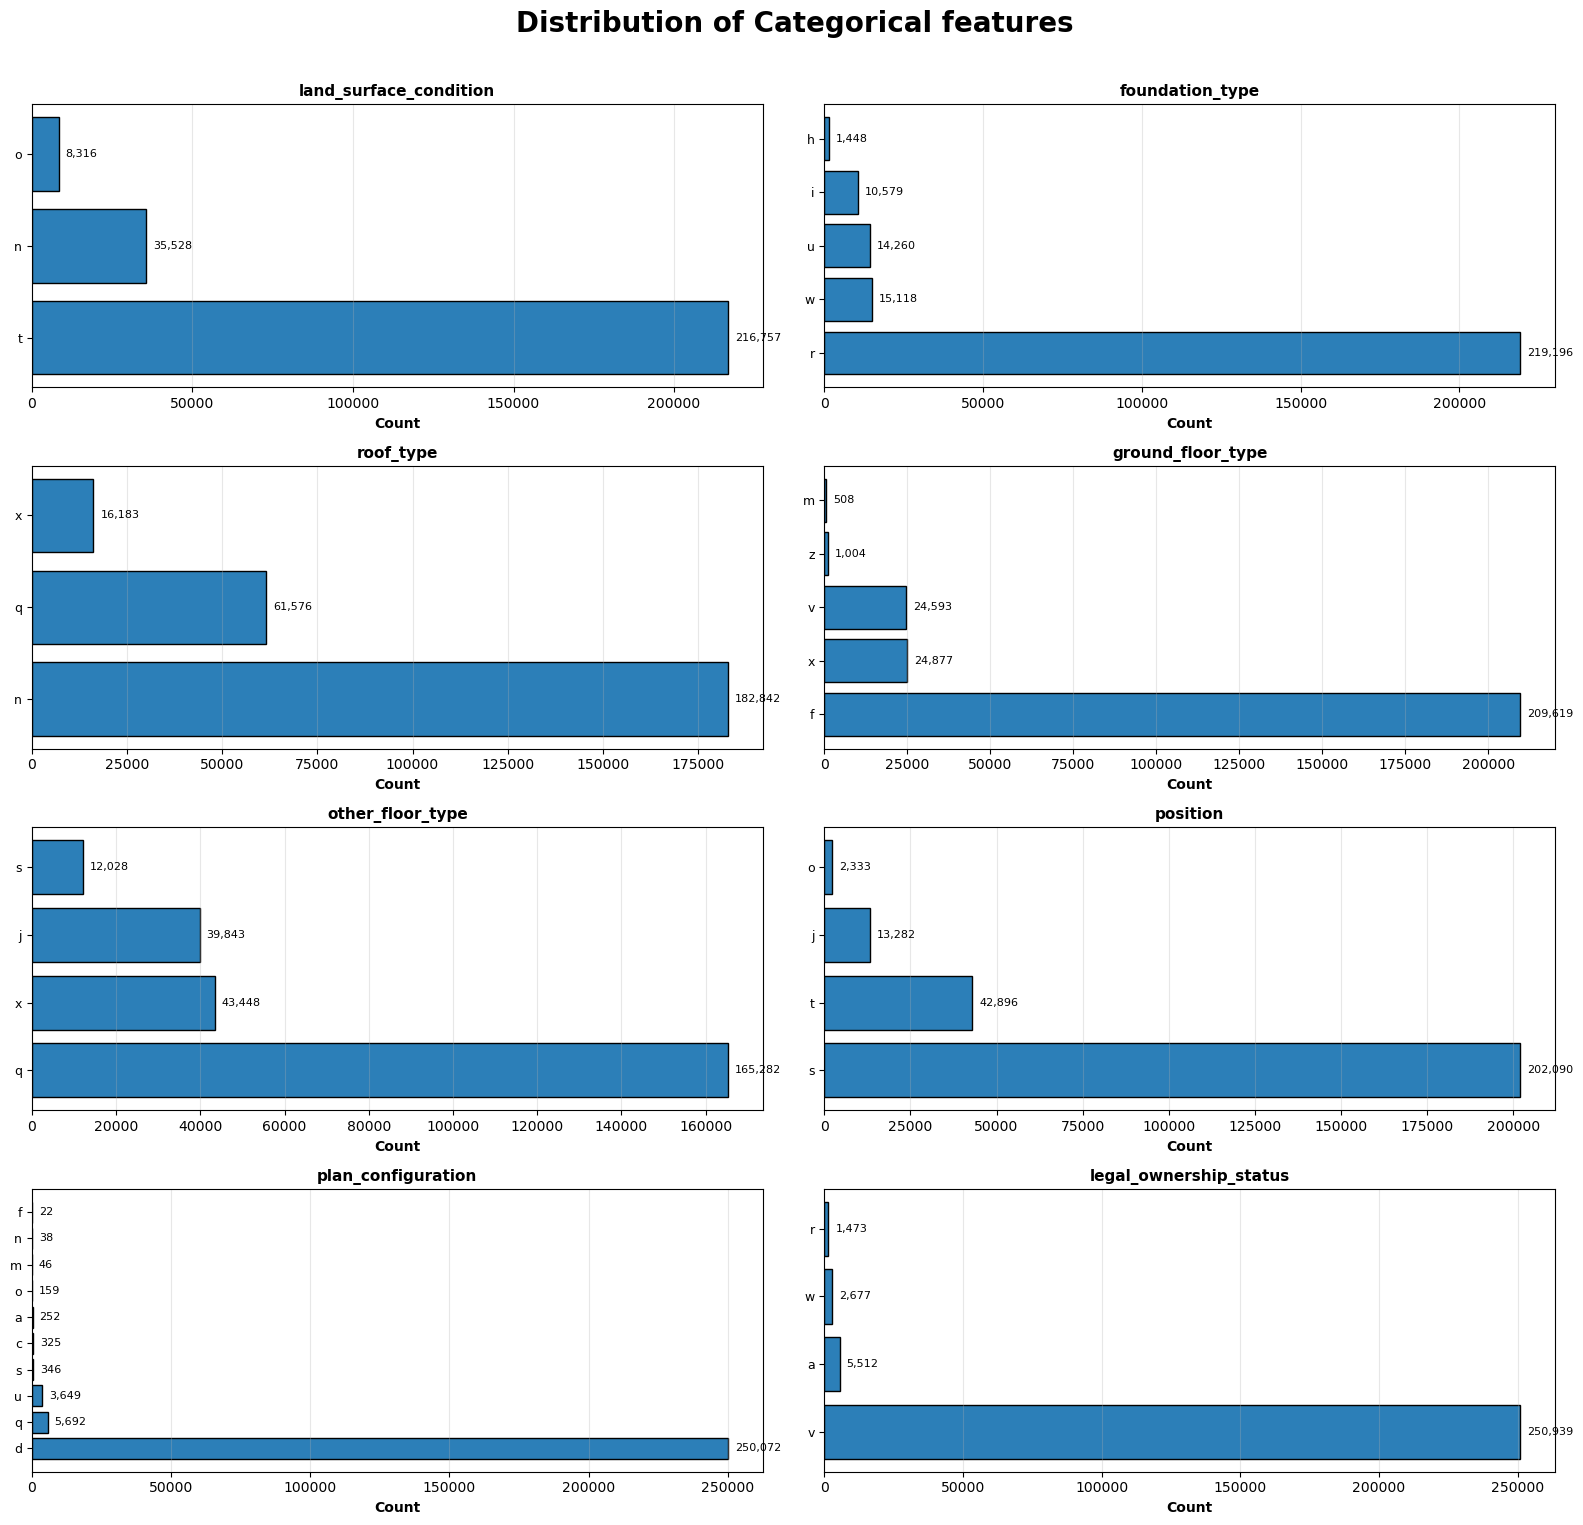

In [125]:
# Distribution of Categorical Features

# Select key categorical features
key_categorical = ['land_surface_condition', 'foundation_type', 'roof_type', 
                   'ground_floor_type', 'other_floor_type', 'position', 
                   'plan_configuration', 'legal_ownership_status']

# Plot categorical distributions
n_cols = 2
n_rows = (len(key_categorical) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows*4))
axes = axes.flatten()

for idx, col in enumerate(key_categorical):
    value_counts = df_eda[col].value_counts().head(10)  # Top 10 categories
    
    axes[idx].barh(range(len(value_counts)), value_counts.values, color='#2c7fb8', edgecolor='black')
    axes[idx].set_yticks(range(len(value_counts)))
    axes[idx].set_yticklabels(value_counts.index, fontsize=9)
    axes[idx].set_xlabel('Count', fontsize=10, fontweight='bold')
    axes[idx].set_title(f'{col}', fontsize=11, fontweight='bold')
    axes[idx].grid(axis='x', alpha=0.3)
    
    # Add value labels
    for i, v in enumerate(value_counts.values):
        axes[idx].text(v + max(value_counts.values)*0.01, i, f'{v:,}', 
                      va='center', fontsize=8)

for idx in range(len(key_categorical), len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle('Distribution of Categorical features', fontsize=20, fontweight='bold', y=0.95)
# Adjust tight_layout to leave room at the top
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

* The categorical features in this dataset predominantly exhibit highly imbalanced distributions, with specific classes—such as mud-mortar stone foundations—dominating the majority of the samples.
* We utilized frequency counts  to identify these dominant modes and highlight the scarcity of minority categories like reinforced concrete.
* High-cardinality features, particularly the geographic identifiers, reveal a multimodal distribution that reflects varying building densities across different earthquake-affected zones.
* This analysis revealed a significant sampling bias toward traditional construction methods, which is a critical factor for the model's predictive logic.
* Understanding these distributions was essential for selecting appropriate encoding strategies and ensuring the model effectively captures the characteristics of both common and rare building types.

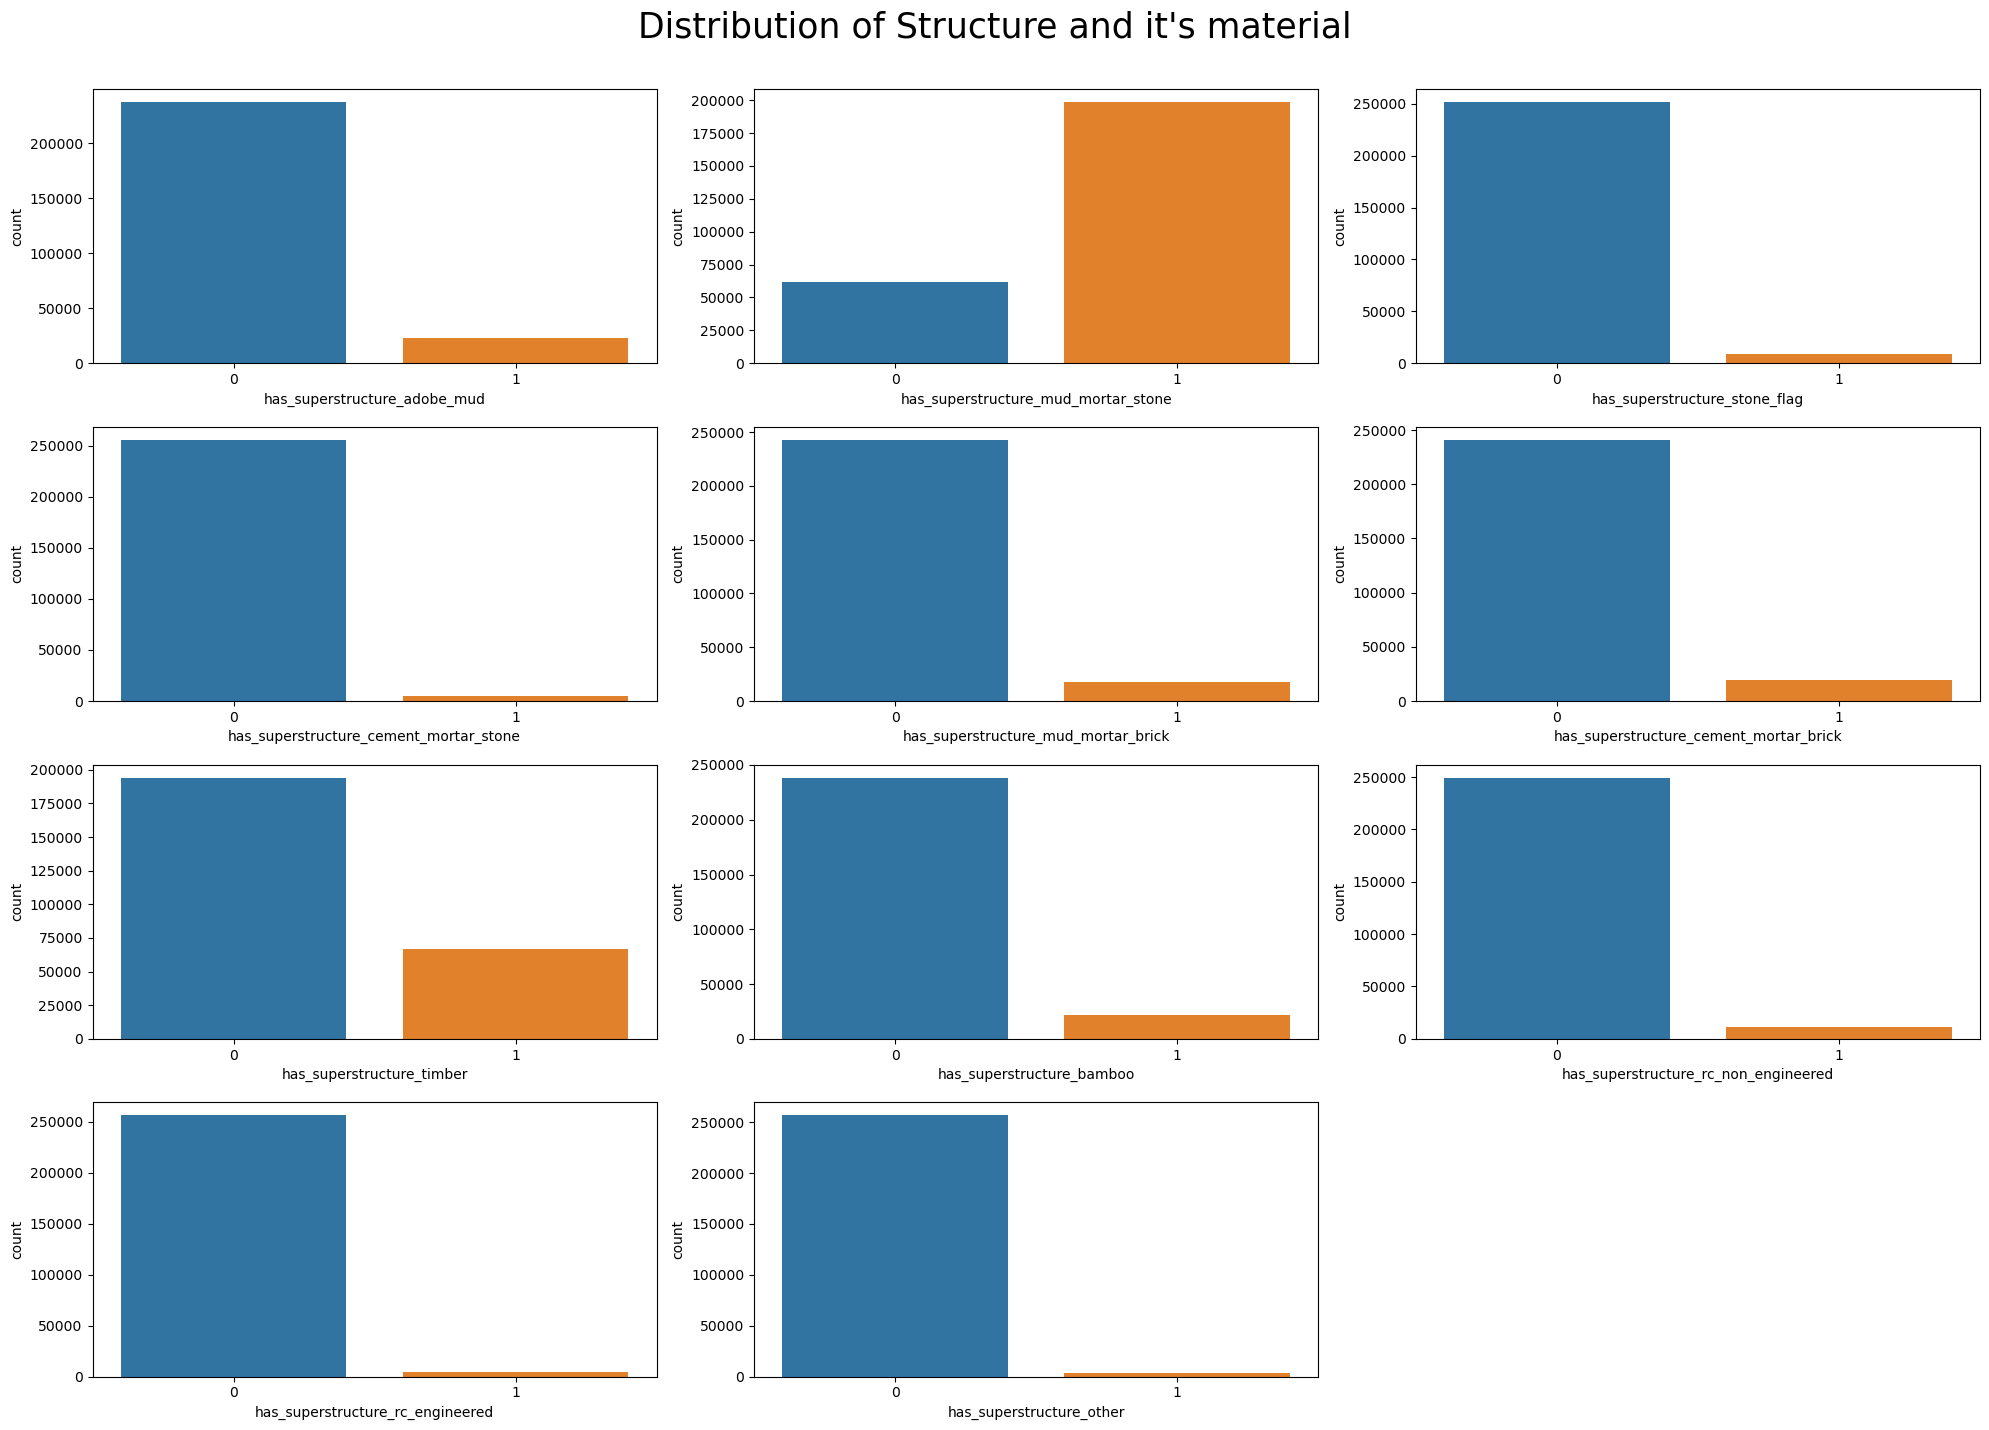

In [39]:
# Delete it
super_cols = ['has_superstructure_adobe_mud','has_superstructure_mud_mortar_stone','has_superstructure_stone_flag',
              'has_superstructure_cement_mortar_stone','has_superstructure_mud_mortar_brick','has_superstructure_cement_mortar_brick',
              'has_superstructure_timber','has_superstructure_bamboo','has_superstructure_rc_non_engineered', 'has_superstructure_rc_engineered',
              'has_superstructure_other']
pltnum=1
plt.figure(figsize=(20,15))
for col in super_cols:
    plt.subplot(4,3,pltnum)
    sns.countplot(x=data[col])
    pltnum+=1

plt.suptitle("Distribution of Structure and it's material", fontsize=25, y=0.95)
# Adjust tight_layout to leave room at the top
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

* This is the defining feature of the dataset. The vast majority of buildings use mud mortar stone, which is known to be seismically vulnerable.
* Modern, engineered materials are rare (Sparse Features). This highlights the economic context of the region: widespread use of traditional, affordable materials over modern, resilient ones.

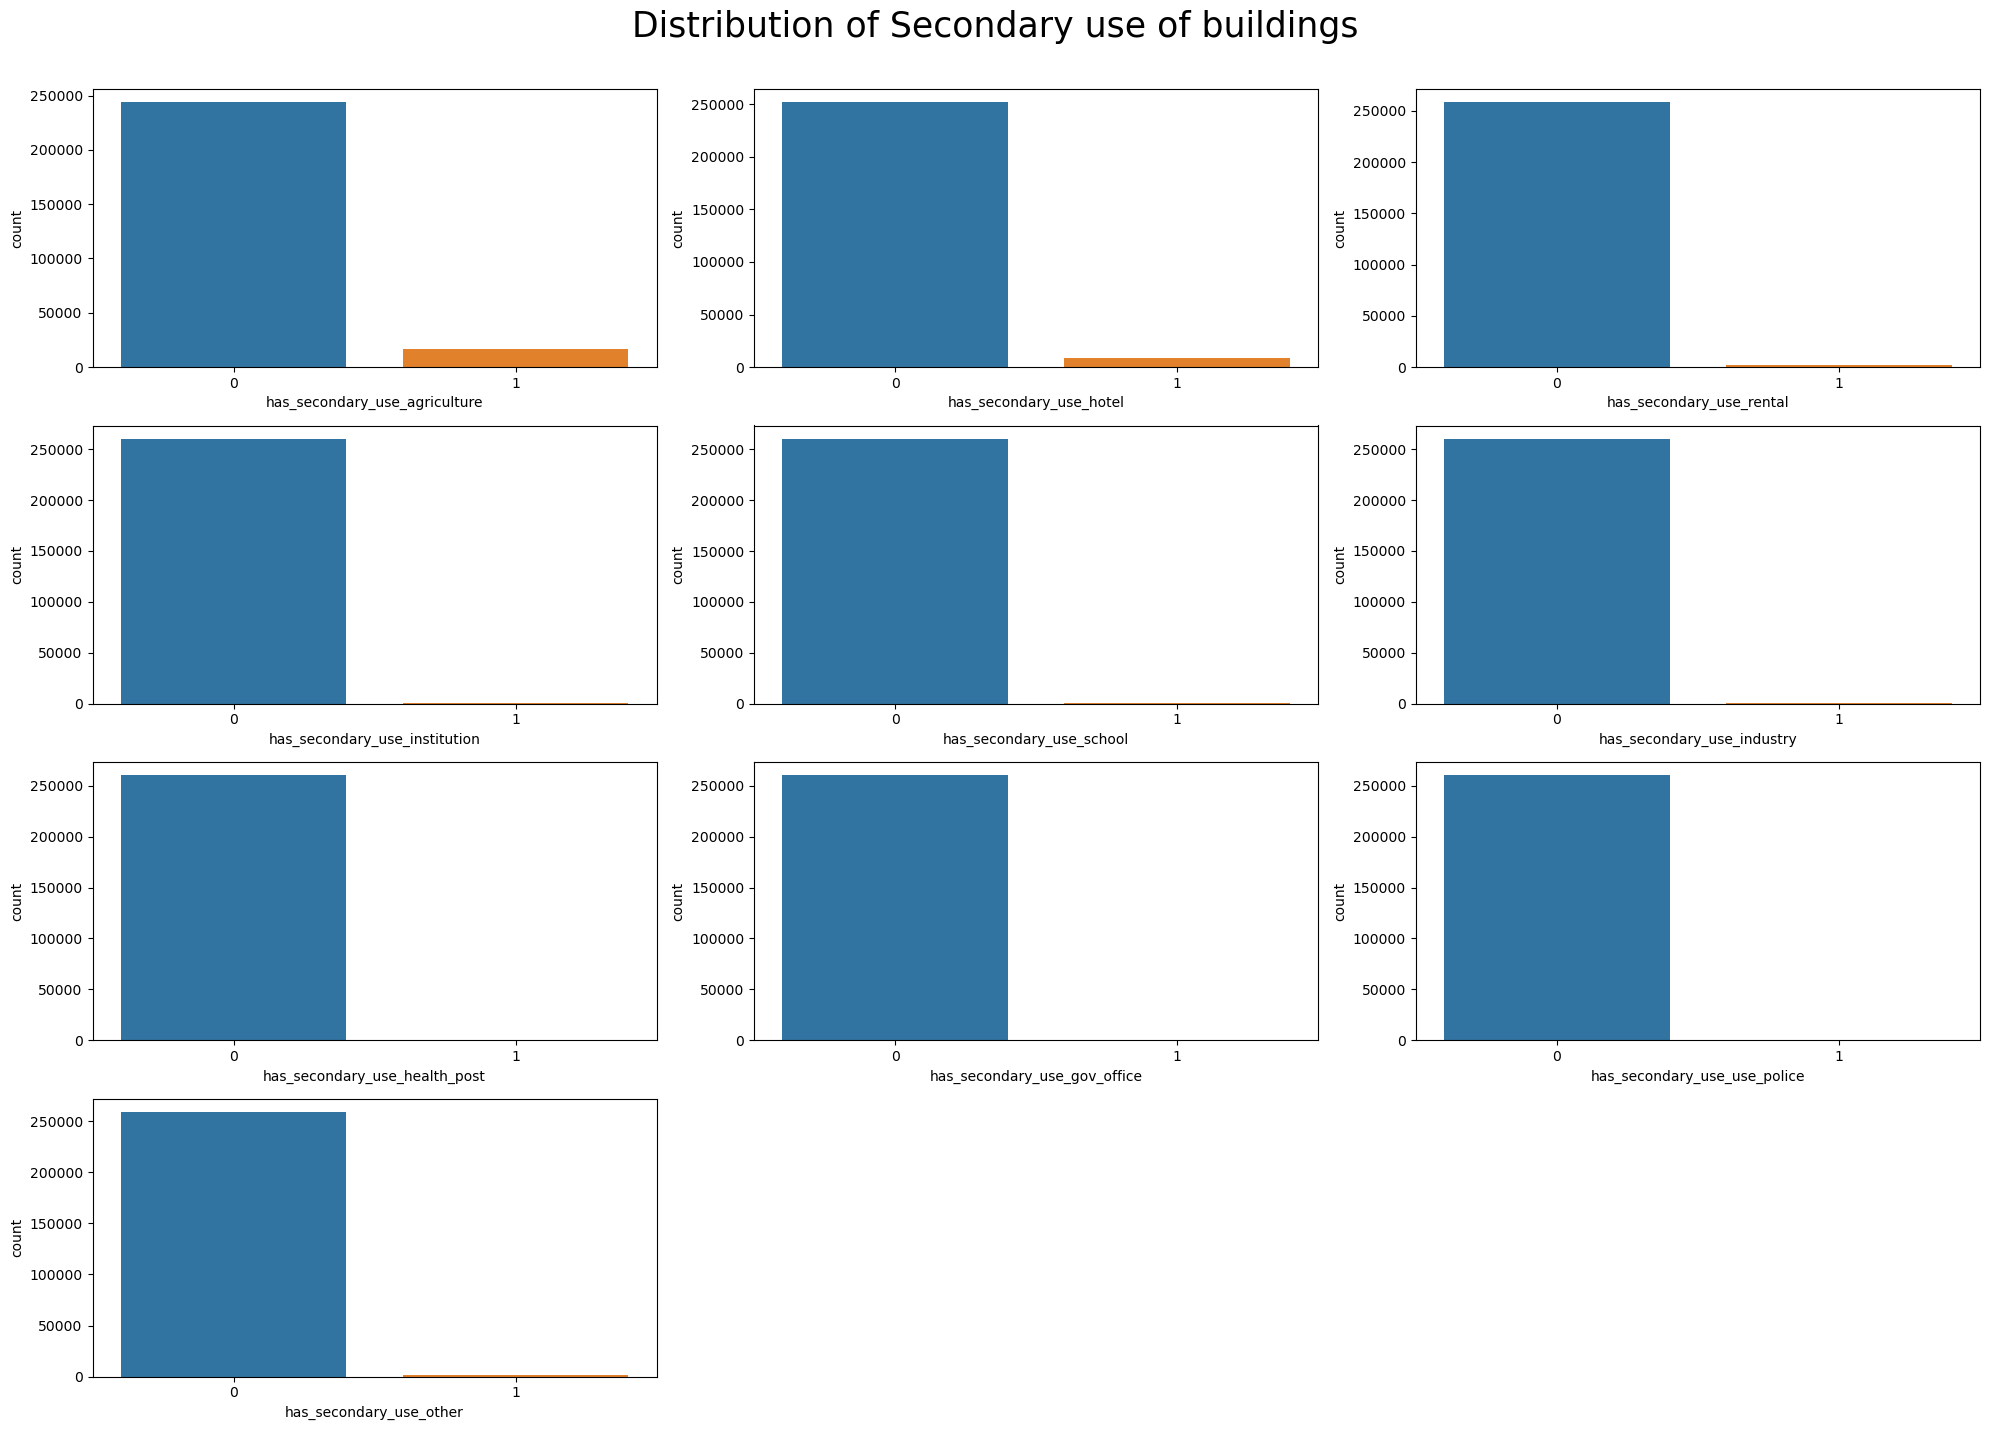

In [42]:
# visual representation of secondary use .
secondary_cols = ['has_secondary_use_agriculture','has_secondary_use_hotel','has_secondary_use_rental','has_secondary_use_institution',
                  'has_secondary_use_school','has_secondary_use_industry','has_secondary_use_health_post',
                  'has_secondary_use_gov_office','has_secondary_use_use_police','has_secondary_use_other']
pltnum=1
plt.figure(figsize=(20,15))
for col in secondary_cols:
    plt.subplot(4,3,pltnum)
    sns.countplot(x=data[col])
    pltnum+=1

plt.suptitle("Distribution of Secondary use of buildings", fontsize=25, y=0.95)
# Adjust tight_layout to leave room at the top
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

* Most buildings are purely residential. Mixed-use buildings are a minority.
* These are extremely sparse classes. Predicting damage specifically for a 'Health Post' will be statistically difficult because we have so few examples of them.
* The dataset is dominated by residential buildings. Categories like 'Police' or 'Health Post' are extremely rare (sparse features). While they are important for context, their low frequency makes them difficult for the model to learn effectively.

### Summary Table

| Feature Type | Column Examples | Processing Technique Used | Reason |
| :--- | :--- | :--- | :--- |
| **Identifier** | `building_id` | **Dropped** | Irrelevant for prediction; prevents overfitting. |
| **Ordinal Target** | `damage_grade` | **None** (already 1,2,3) | Target variable. |
| **High Cardinality** | `geo_level_2`, `geo_level_3` | **Target/Mean Encoding** | Too many unique values for One-Hot; preserves spatial risk info. |
| **Low Cardinality** | `foundation`, `roof_type` | **One-Hot Encoding** | Converts categories to machine-readable binary format. |
| **Numerical** | `age`, `area`, `height` | **Standard Scaling** | Normalizes range (optional for Trees, mandatory for others). |
| **Outliers** | `age` (995) | **Capping / Flagging** | 995 represents "Unknown/Ancient", treated as a special category. |
| **Binary** | `has_superstructure_...` | **Aggregation** | Summed to create `material_count` to detect mixed-construction risks. |

## Bivariate Analysis

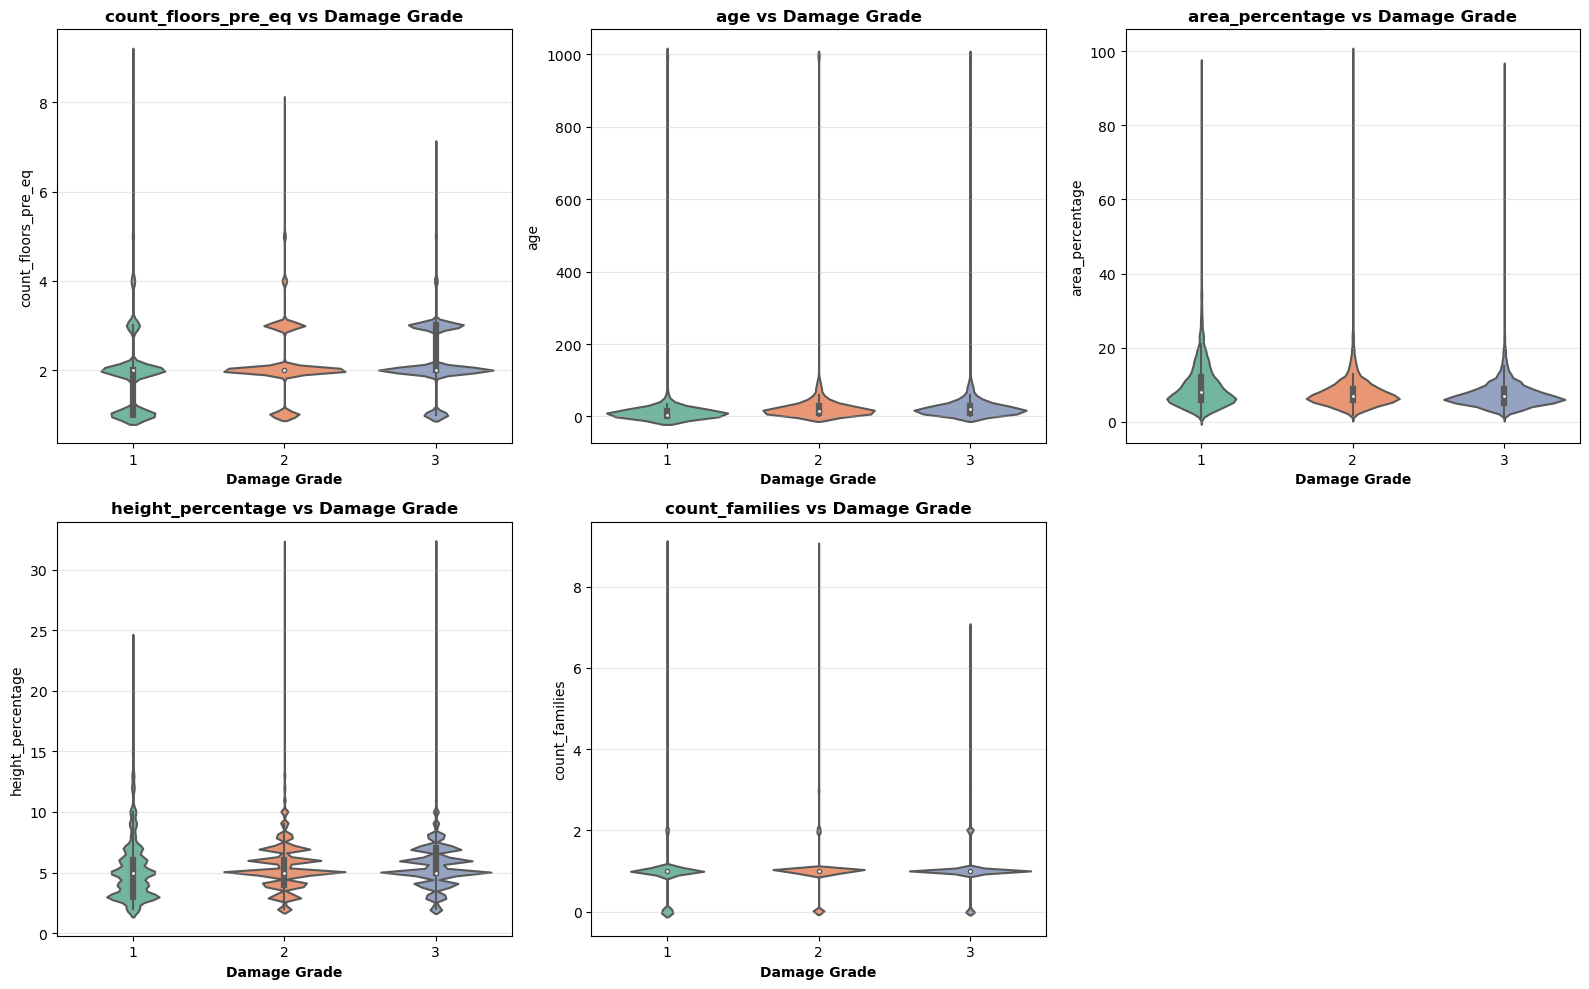

In [129]:
# Numerical features across Damage grade
#  Reveals which numerical features discriminate between damage levels.
# variable with key numerical features
key_num_vs_target = ['count_floors_pre_eq', 'age', 'area_percentage', 
                     'height_percentage', 'count_families']

# Violin plots
n_cols = 3
n_rows = (len(key_num_vs_target) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows*5))
axes = axes.flatten()

for idx, col in enumerate(key_num_vs_target):
    sns.violinplot(data=df_eda, x='damage_grade', y=col, ax=axes[idx], palette='Set2')
    axes[idx].set_title(f'{col} vs Damage Grade', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Damage Grade', fontsize=10, fontweight='bold')
    axes[idx].set_ylabel(col, fontsize=10)
    axes[idx].grid(axis='y', alpha=0.3)

for idx in range(len(key_num_vs_target), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

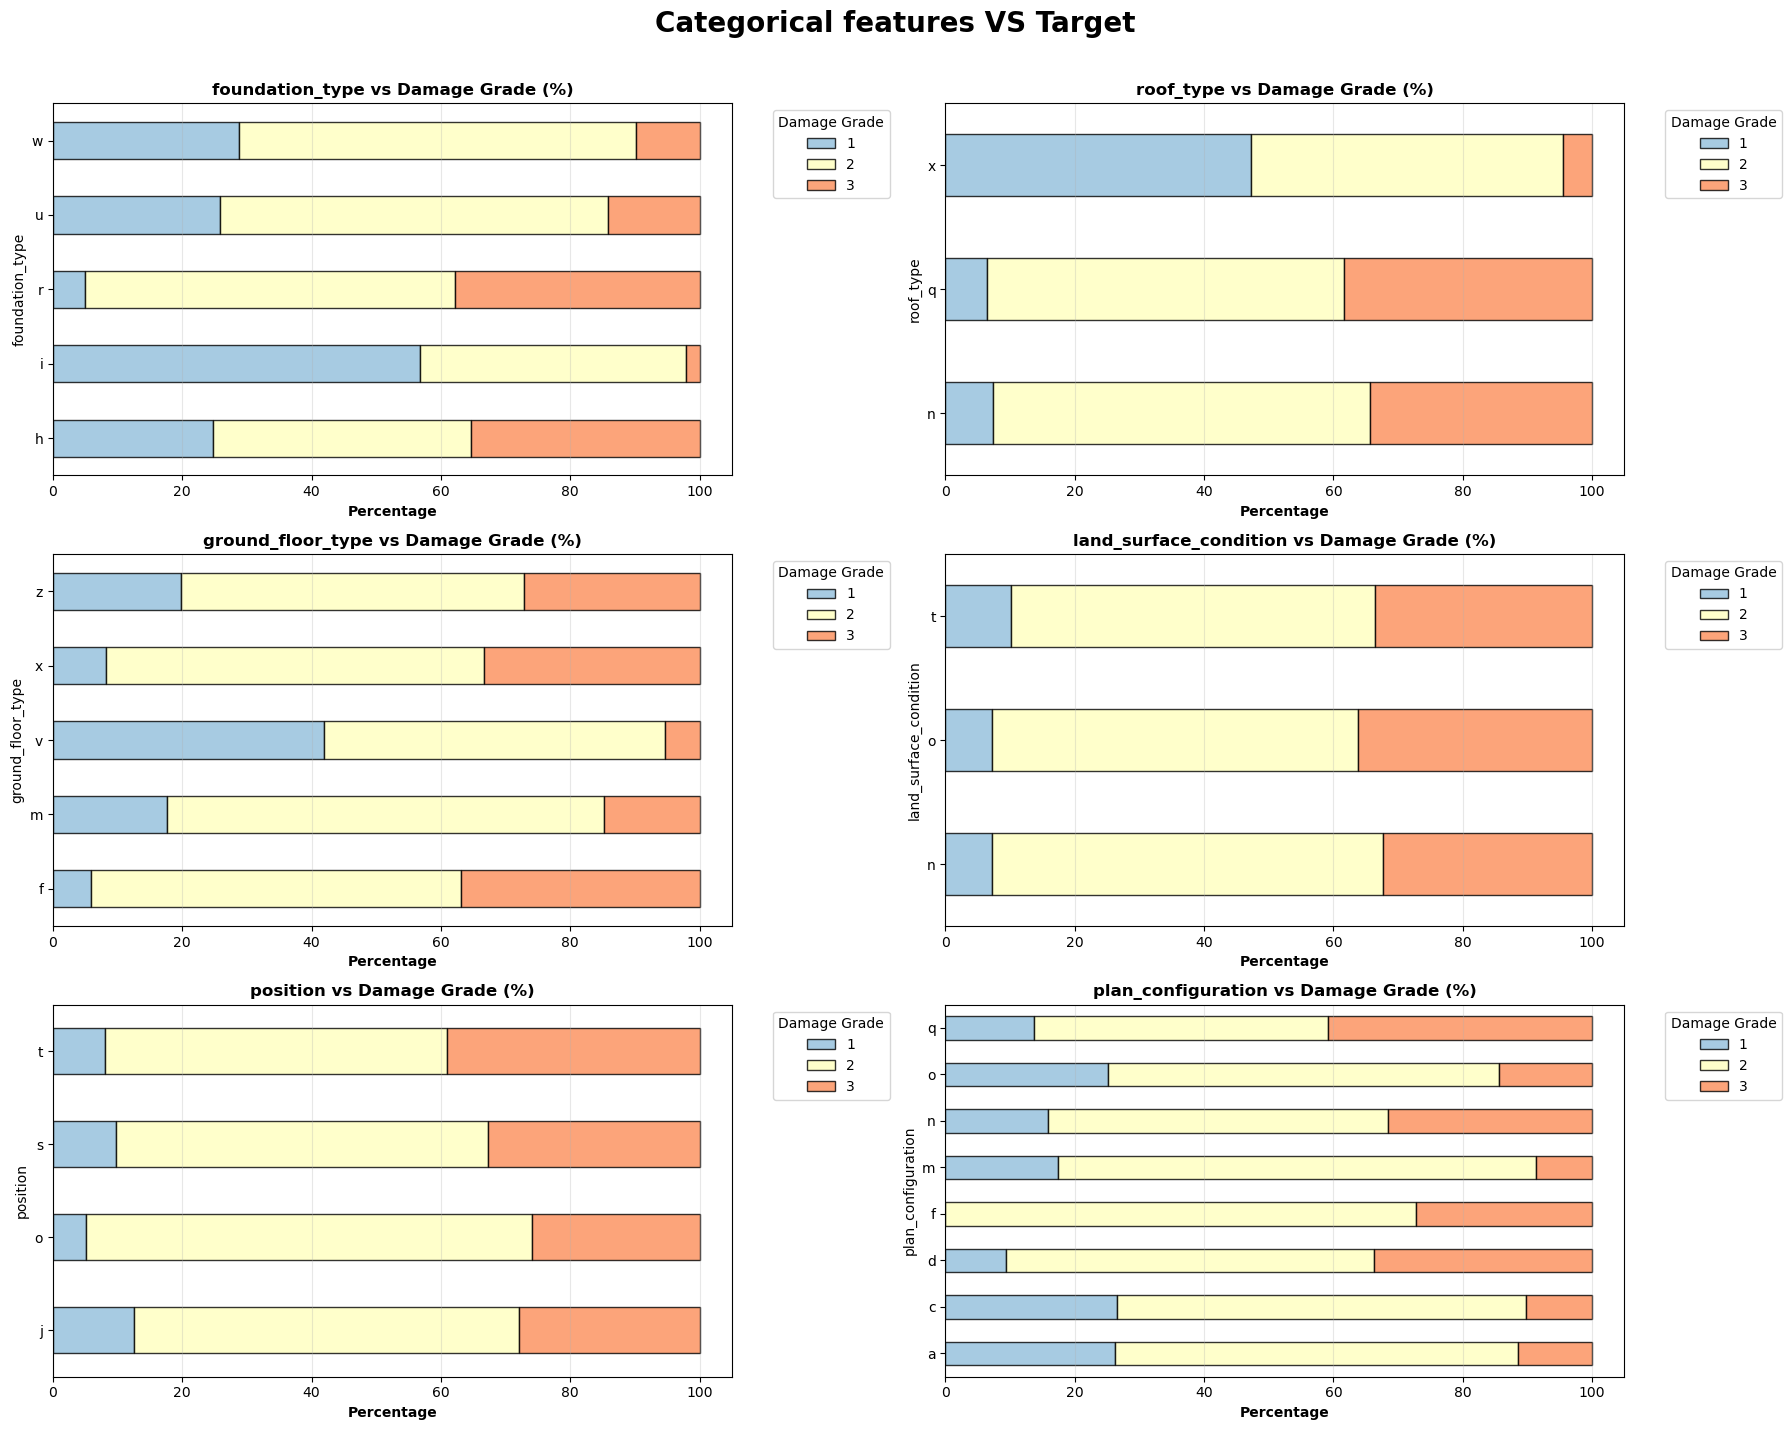

In [135]:
# Categorical Features across Damage grade
# Reveals which categories are associated with higher damage rates.
# Select key categorical features
key_cat_vs_target = ['foundation_type', 'roof_type', 'ground_floor_type', 
                     'land_surface_condition', 'position', 'plan_configuration']

# Stacked bar charts (normalized)
n_cols = 2
n_rows = (len(key_cat_vs_target) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows*5))
axes = axes.flatten()

for idx, col in enumerate(key_cat_vs_target):
    # Create crosstab (normalized)
    ct = pd.crosstab(df_eda[col], df_eda['damage_grade'], normalize='index') * 100
    ct = ct.head(8)  # Top 8 categories
    
    ct.plot(kind='barh', stacked=True, ax=axes[idx], 
            color=['#91bfdb', '#ffffbf', '#fc8d59'], alpha=0.8, edgecolor='black')
    axes[idx].set_title(f'{col} vs Damage Grade (%)', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Percentage', fontsize=10, fontweight='bold')
    axes[idx].set_ylabel(col, fontsize=10)
    axes[idx].legend(title='Damage Grade', bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[idx].grid(axis='x', alpha=0.3)

for idx in range(len(key_cat_vs_target), len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle('Categorical features VS Target', fontsize=20, fontweight='bold', y=0.95)
# Adjust tight_layout to leave room at the top
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

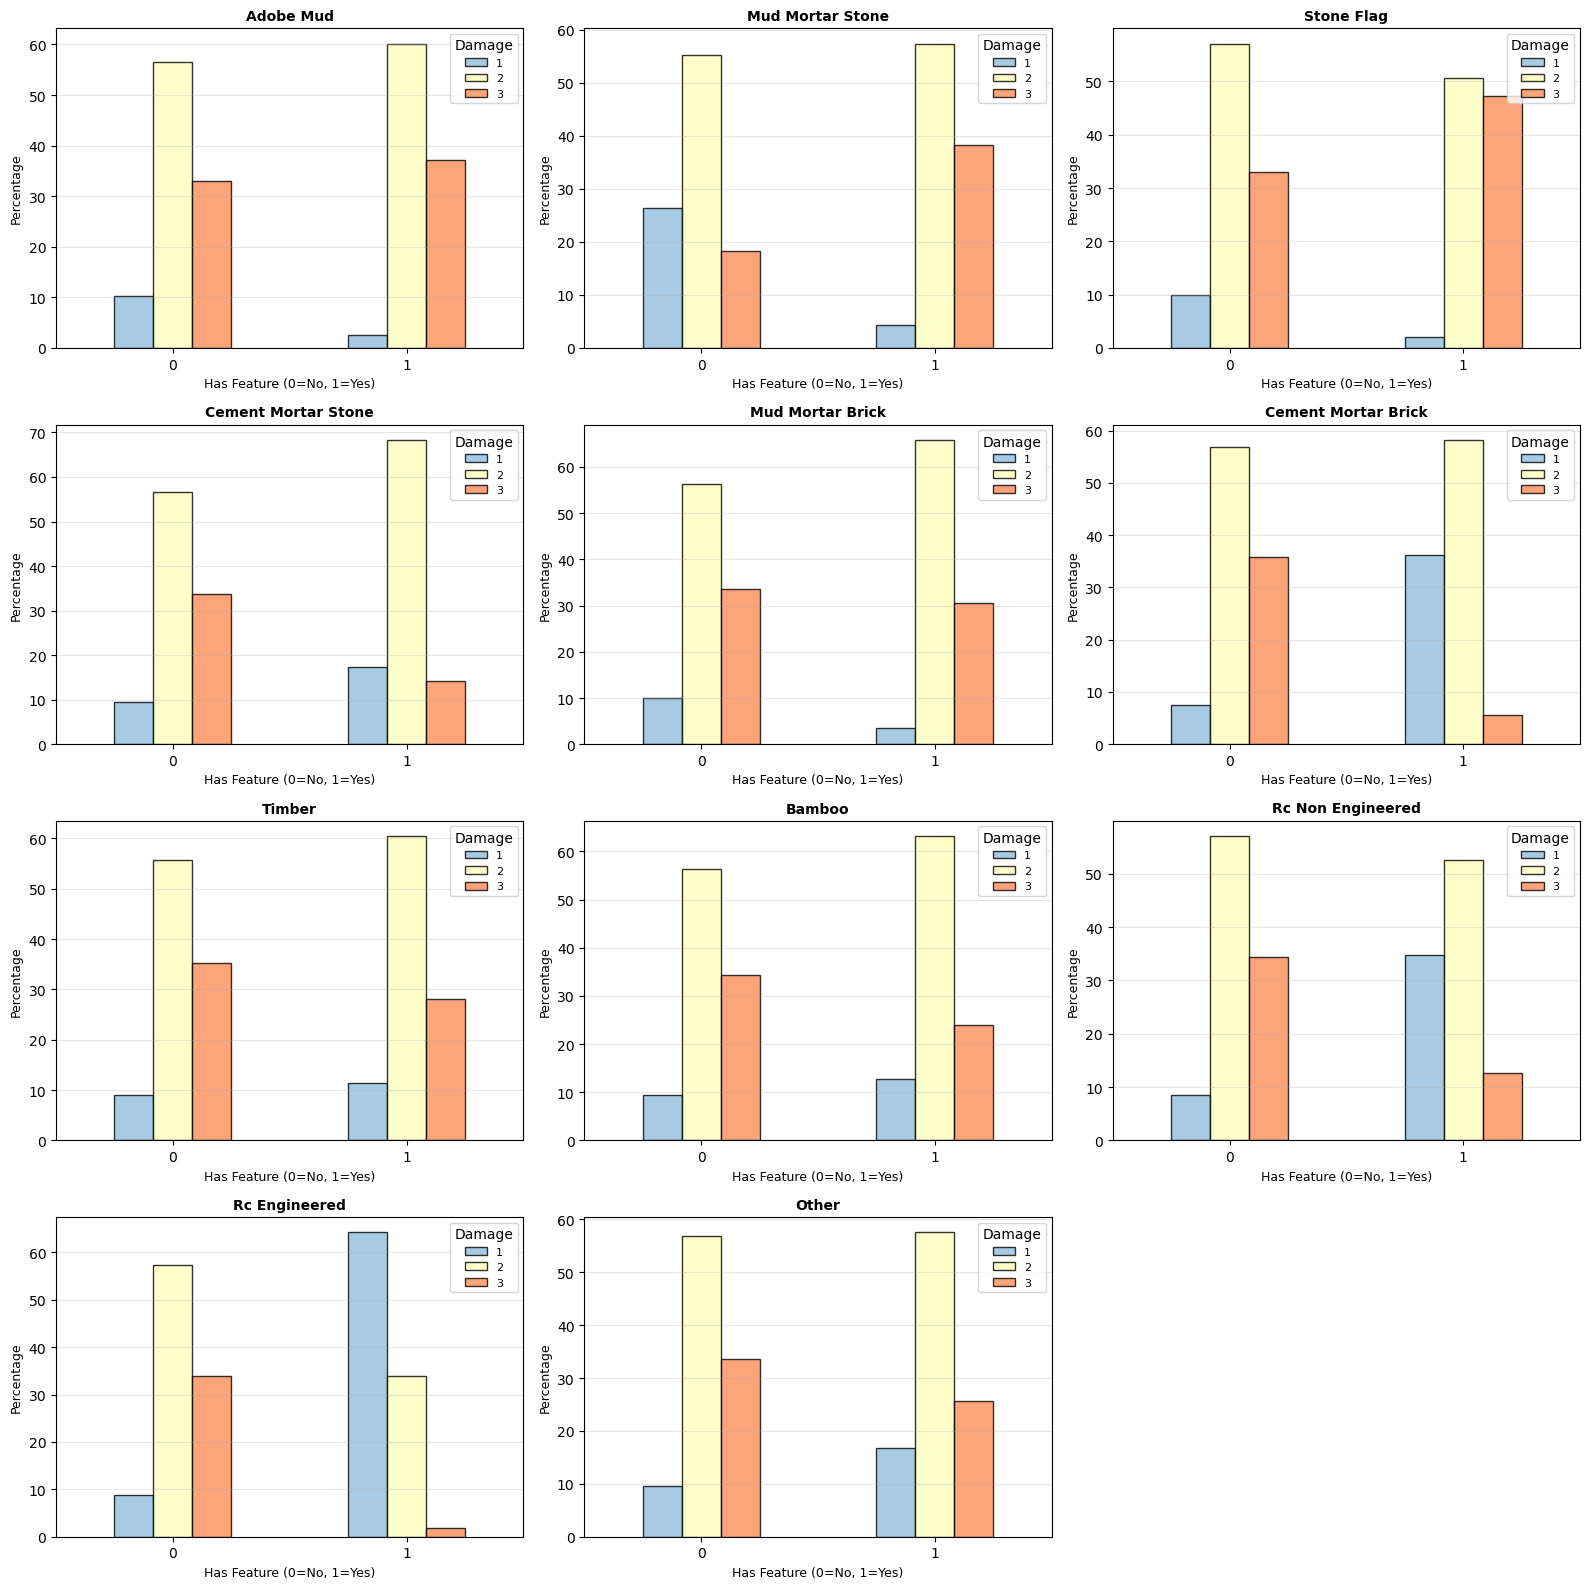

In [149]:
# Superstructure features across Damage grade

# binary superstructure features
binary_features = ['has_superstructure_adobe_mud', 'has_superstructure_mud_mortar_stone',
                   'has_superstructure_stone_flag', 'has_superstructure_cement_mortar_stone',
                   'has_superstructure_mud_mortar_brick', 'has_superstructure_cement_mortar_brick',
                   'has_superstructure_timber', 'has_superstructure_bamboo',
                   'has_superstructure_rc_non_engineered', 'has_superstructure_rc_engineered',
                   'has_superstructure_other']

if len(binary_features) > 0:
    n_cols = 3
    n_rows = (min(len(binary_features), 11) + n_cols - 1) // n_cols  # Show first 9
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows*4))
    axes = axes.flatten()
    
    for idx, col in enumerate(binary_features[:12]):
        ct = pd.crosstab(df_eda[col], df_eda['damage_grade'], normalize='index') * 100
        ct.plot(kind='bar', ax=axes[idx], color=['#91bfdb', '#ffffbf', '#fc8d59'], 
                alpha=0.8, edgecolor='black')
        
        # Shorten title
        short_name = col.replace('has_superstructure_', '').replace('_', ' ').title()
        axes[idx].set_title(short_name, fontsize=10, fontweight='bold')
        axes[idx].set_xlabel('Has Feature (0=No, 1=Yes)', fontsize=9)
        axes[idx].set_ylabel('Percentage', fontsize=9)
        axes[idx].legend(title='Damage', fontsize=8, loc='upper right')
        axes[idx].grid(axis='y', alpha=0.3)
        axes[idx].tick_params(axis='x', rotation=0)
    
    for idx in range(min(len(binary_features), 12), len(axes)):
        fig.delaxes(axes[idx])
    
    plt.tight_layout()
    plt.show()

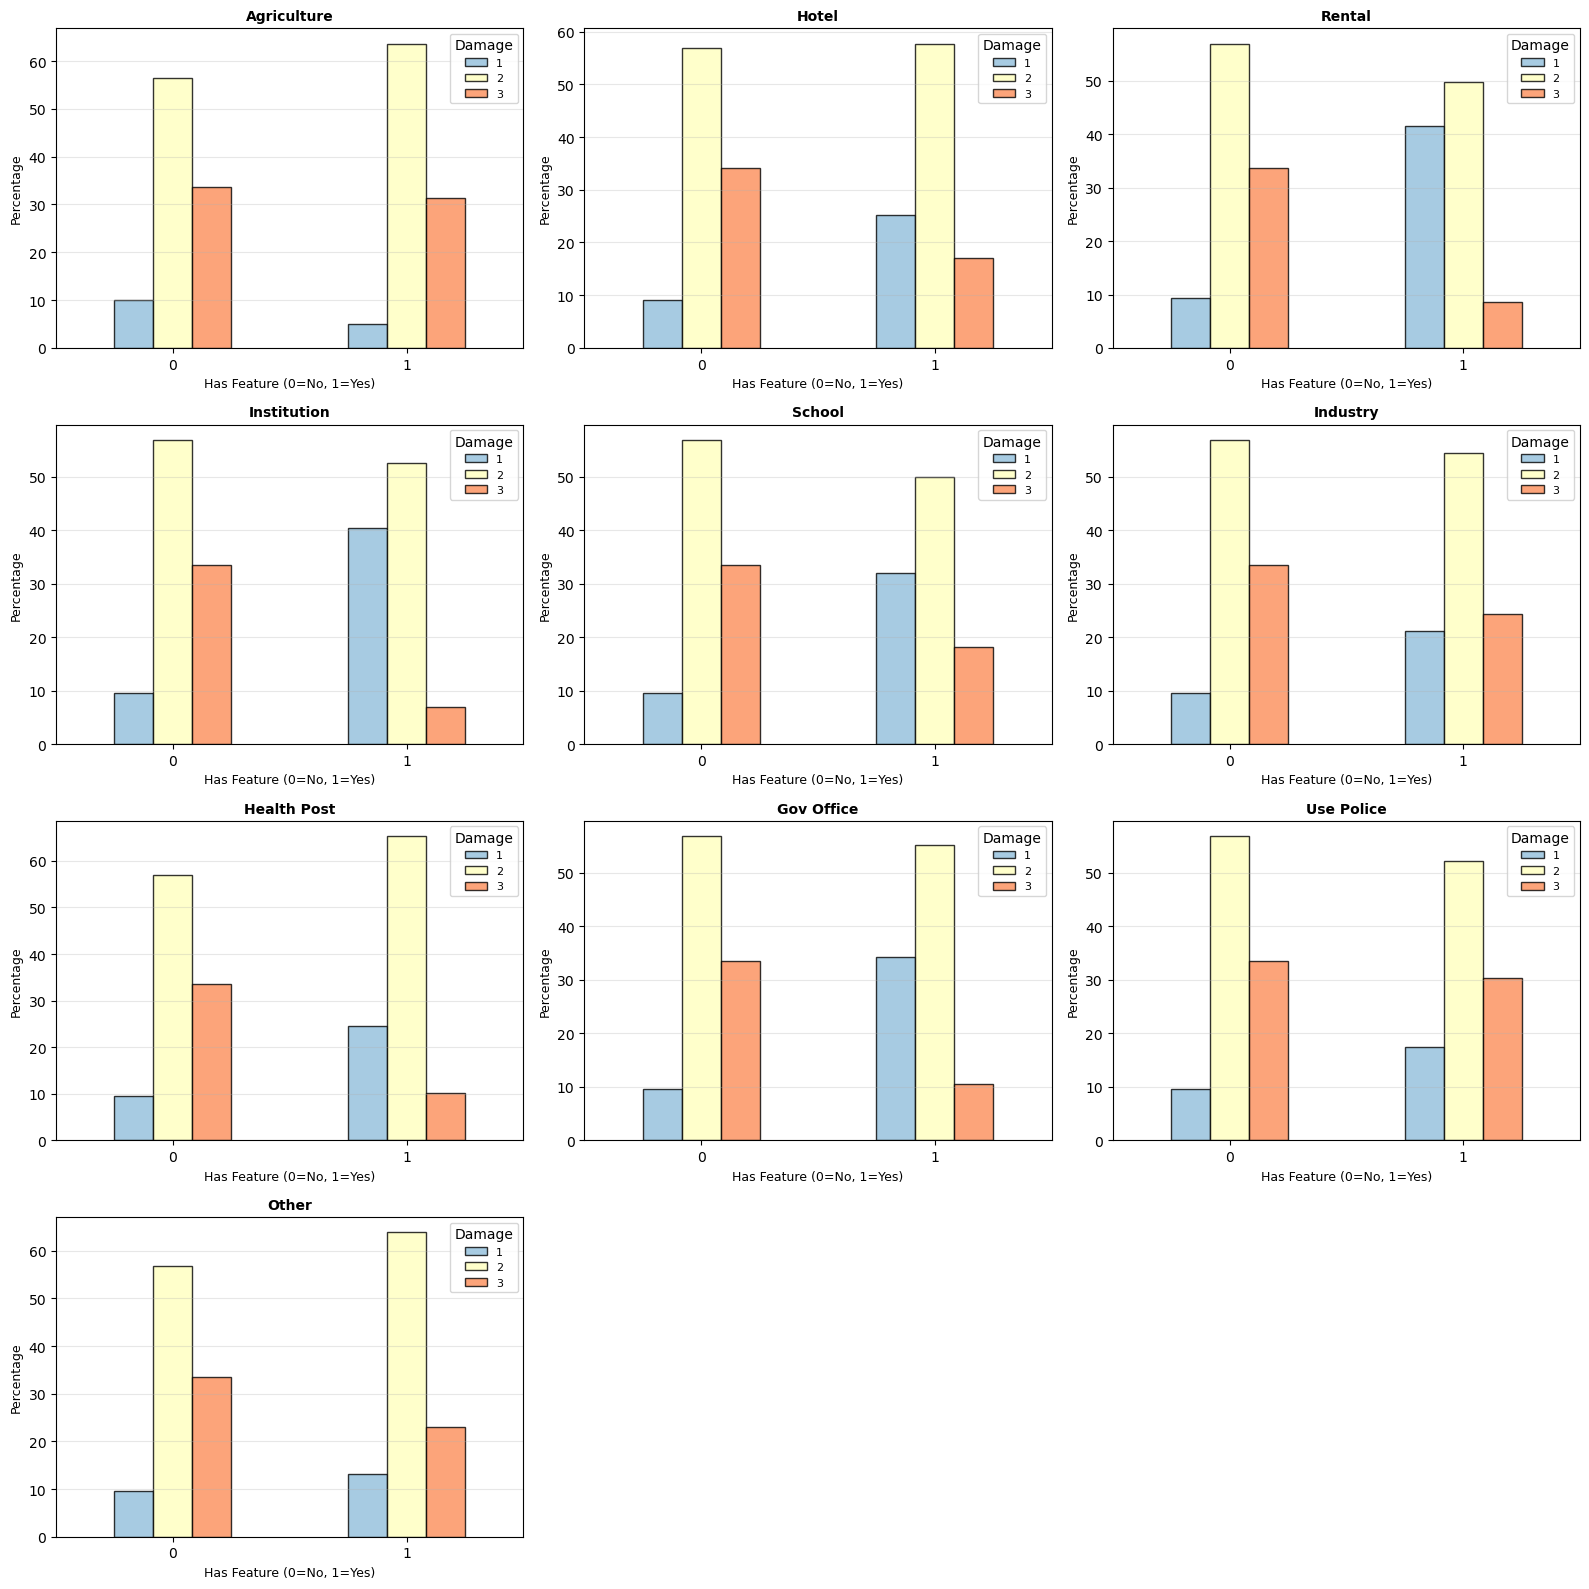

In [147]:
# Secondary use features across Damage grade
# One-hot encoded features show which materials lead to higher damage.
# binary secondary use features
secondary_cols = ['has_secondary_use_agriculture','has_secondary_use_hotel','has_secondary_use_rental','has_secondary_use_institution',
                  'has_secondary_use_school','has_secondary_use_industry','has_secondary_use_health_post',
                  'has_secondary_use_gov_office','has_secondary_use_use_police','has_secondary_use_other']

if len(secondary_cols) > 0:
    n_cols = 3
    n_rows = (min(len(secondary_cols), 11) + n_cols - 1) // n_cols  # Show first 9
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows*4))
    axes = axes.flatten()
    
    for idx, col in enumerate(secondary_cols[:11]):
        ct = pd.crosstab(df_eda[col], df_eda['damage_grade'], normalize='index') * 100
        ct.plot(kind='bar', ax=axes[idx], color=['#91bfdb', '#ffffbf', '#fc8d59'], 
                alpha=0.8, edgecolor='black')
        
        # Shorten title
        short_name = col.replace('has_secondary_use_', '').replace('_', ' ').title()
        axes[idx].set_title(short_name, fontsize=10, fontweight='bold')
        axes[idx].set_xlabel('Has Feature (0=No, 1=Yes)', fontsize=9)
        axes[idx].set_ylabel('Percentage', fontsize=9)
        axes[idx].legend(title='Damage', fontsize=8, loc='upper right')
        axes[idx].grid(axis='y', alpha=0.3)
        axes[idx].tick_params(axis='x', rotation=0)
    
    for idx in range(min(len(secondary_cols), 11), len(axes)):
        fig.delaxes(axes[idx])
    
    plt.tight_layout()
    plt.show()

## Multivariate Analysis

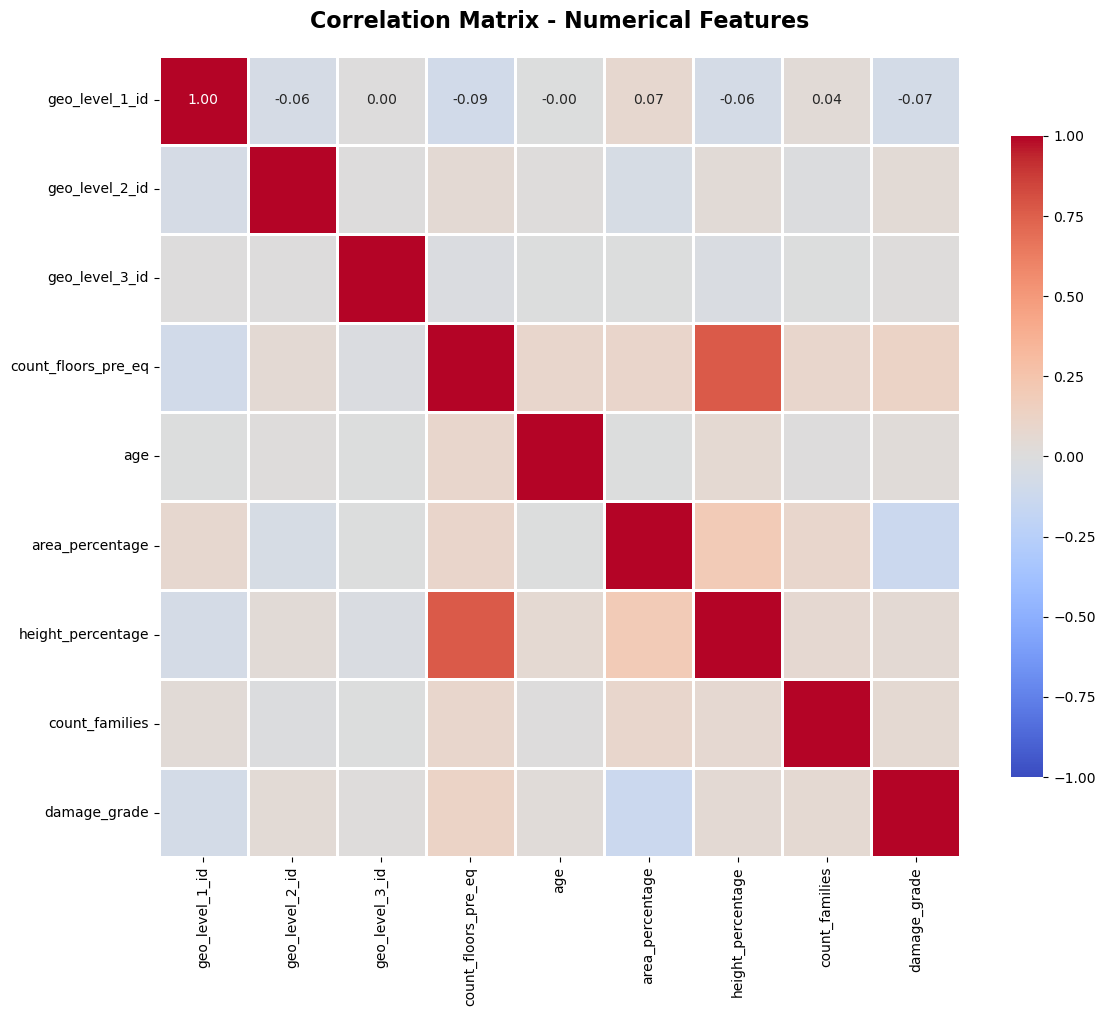

In [151]:
# Correlation matrix
# Shows linear relationships between ALL numerical features. High correlations indicate potential multicollinearity.
# Select features for correlation
corr_features = ['geo_level_1_id', 'geo_level_2_id', 'geo_level_3_id',
                 'count_floors_pre_eq', 'age', 'area_percentage',
                 'height_percentage', 'count_families', 'damage_grade']

corr_matrix = df_eda[corr_features].corr()

# Plot correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1)
plt.title('Correlation Matrix - Numerical Features', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

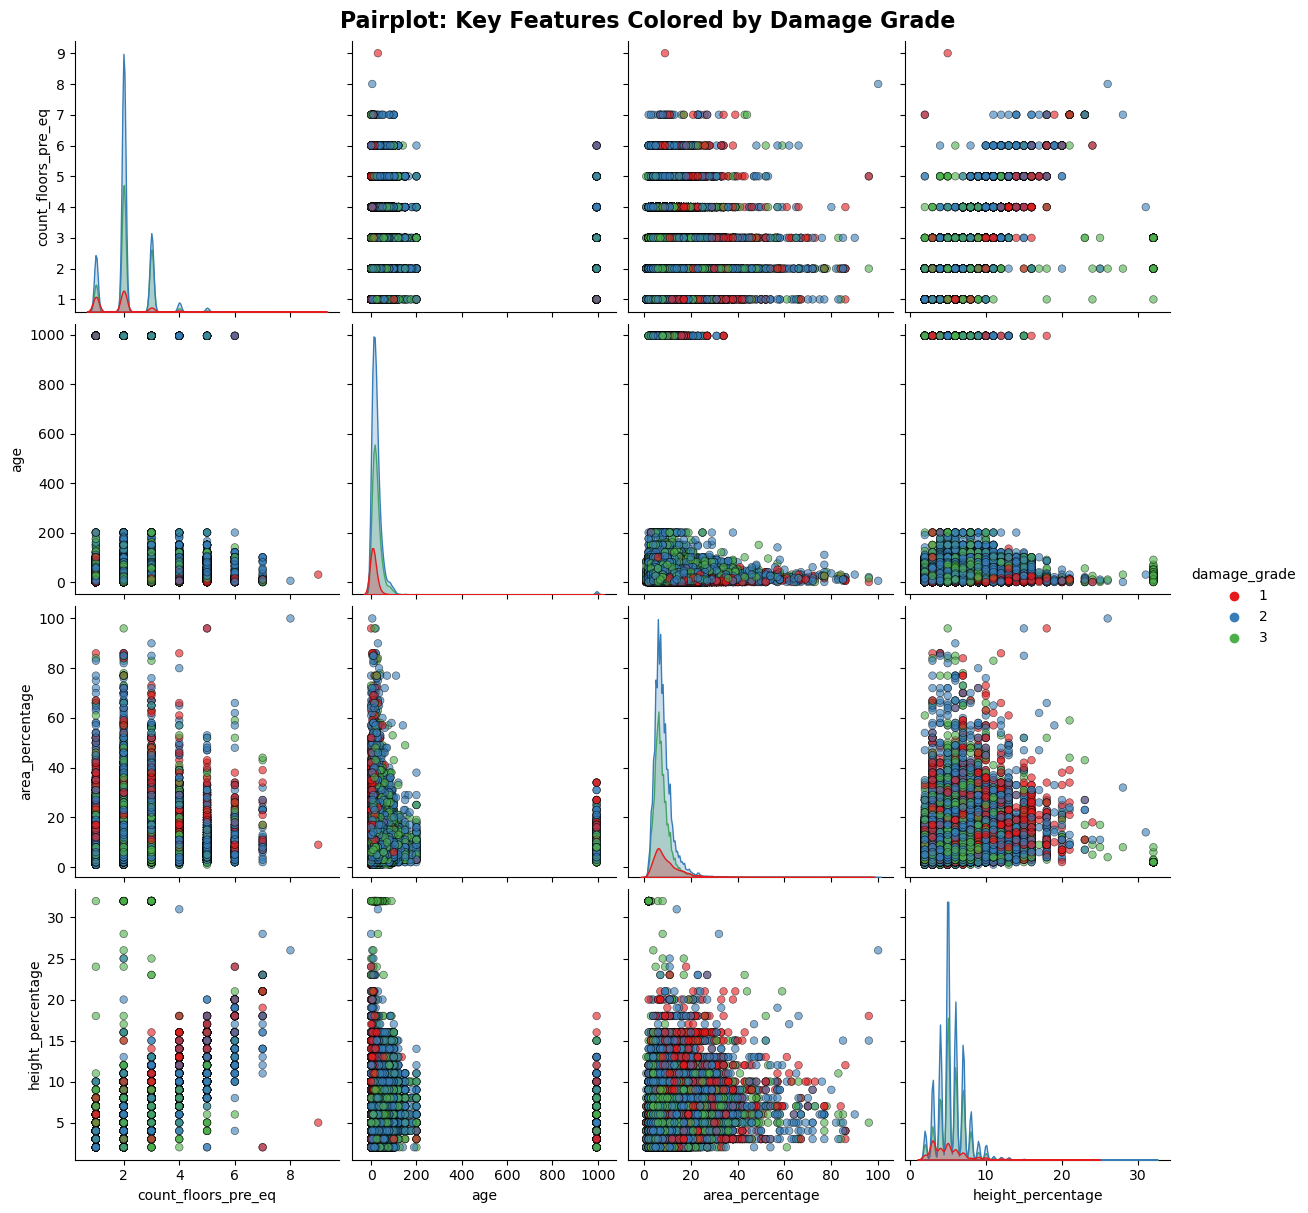


✅ Pairplot created!


In [153]:
# Poir plot of numerical feature and target variable
# Shows ALL pairwise relationships at once. Reveals patterns across multiple dimensions that individual plots miss.
# Key numerical feature and target variable
pairplot_features = ['count_floors_pre_eq', 'age', 'area_percentage', 
                     'height_percentage', 'damage_grade']

# Sample of only numerical features and target variable
df_pairplot = df_eda[pairplot_features]


# Create pairplot
g = sns.pairplot(df_pairplot, hue='damage_grade', palette='Set1', 
                 diag_kind='kde', plot_kws={'alpha': 0.6, 's': 30, 'edgecolor': 'k'},
                 height=3)
g.fig.suptitle('Pairplot: Key Features Colored by Damage Grade', 
               y=1.01, fontsize=16, fontweight='bold')
plt.show()

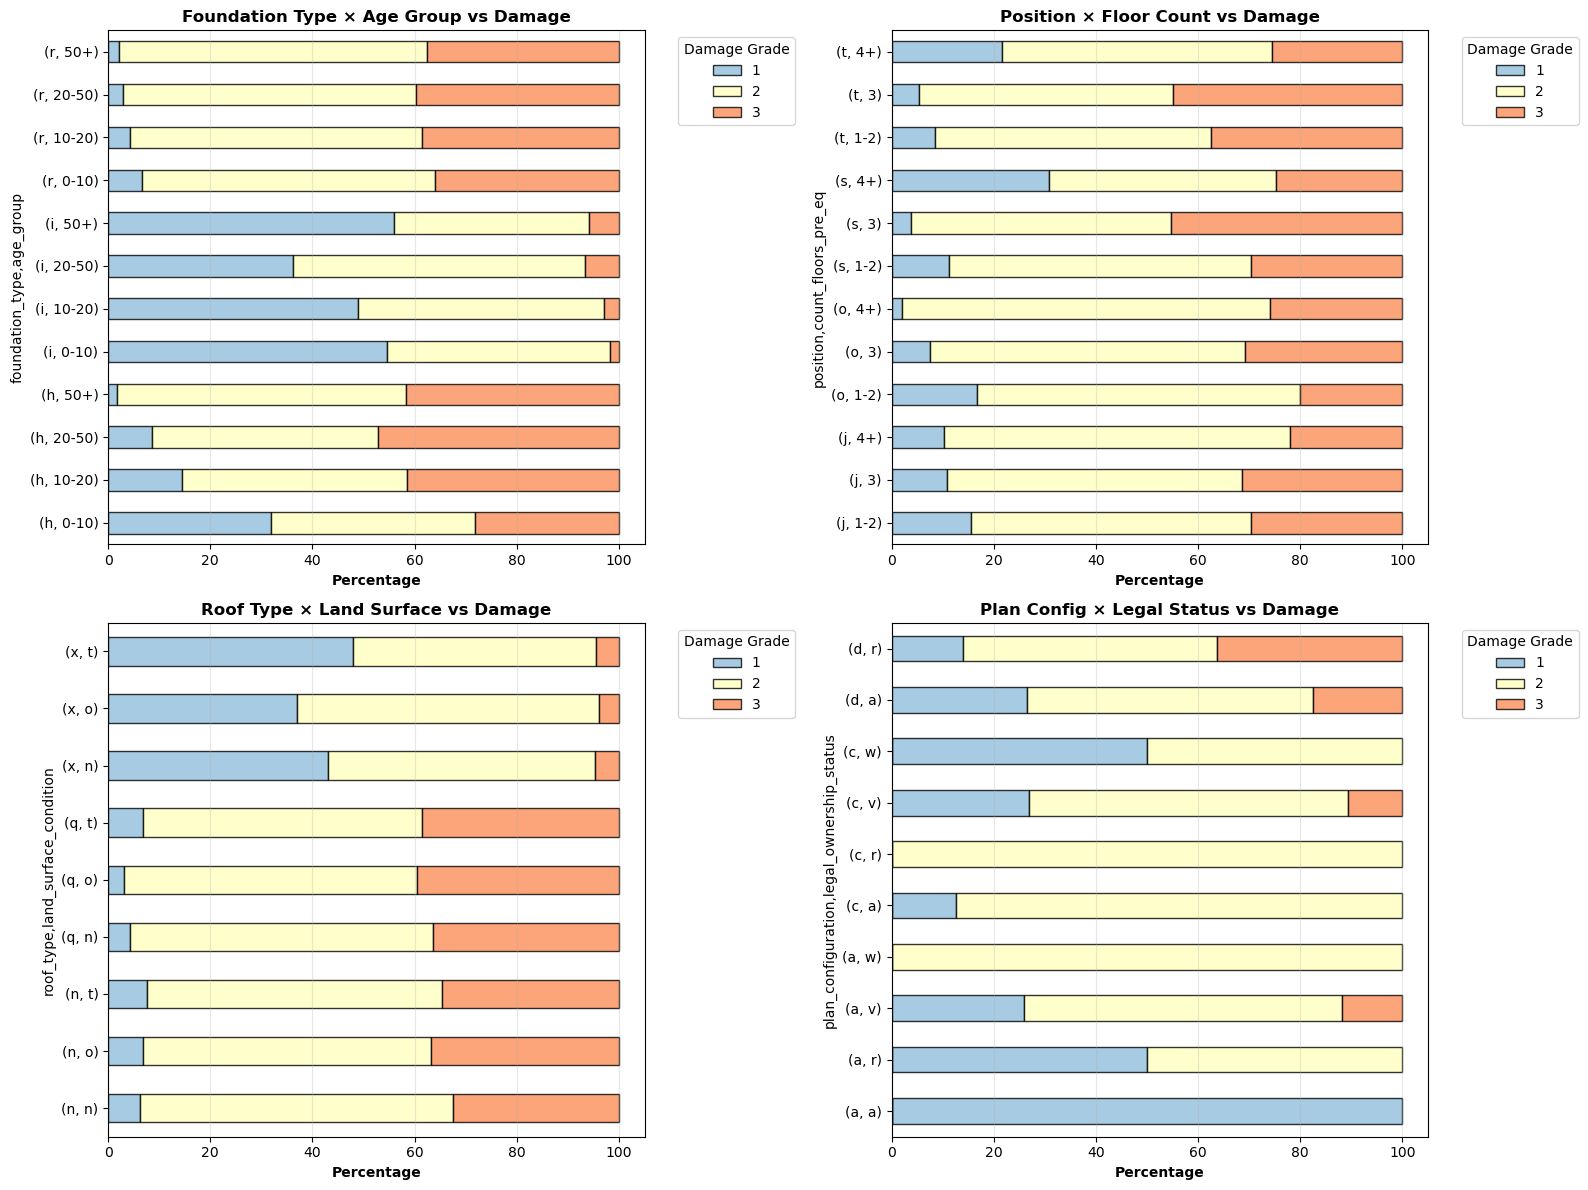

In [157]:
# Interaction features across Damage grade
# Shows how COMBINATIONS of features affect damage. Single features might be weak, but combinations can be powerful

# Create age groups for interaction analysis
df_eda['age_group'] = pd.cut(df_eda['age'], bins=[0, 10, 20, 50, 1000], 
                          labels=['0-10', '10-20', '20-50', '50+'])

# Interaction plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Foundation Type × Age Group
ct1 = pd.crosstab([df_eda['foundation_type'], df_eda['age_group']], df_eda['damage_grade'], normalize='index') * 100
ct1_top = ct1.head(12)
ct1_top.plot(kind='barh', stacked=True, ax=axes[0, 0], 
             color=['#91bfdb', '#ffffbf', '#fc8d59'], alpha=0.8, edgecolor='black')
axes[0, 0].set_title('Foundation Type × Age Group vs Damage', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Percentage', fontsize=10, fontweight='bold')
axes[0, 0].legend(title='Damage Grade', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0, 0].grid(axis='x', alpha=0.3)

# 2. Position × Floor Count
ct2 = pd.crosstab([df_eda['position'], pd.cut(df_eda['count_floors_pre_eq'], bins=[0, 2, 3, 10], 
                                            labels=['1-2', '3', '4+'])], 
                   df_eda['damage_grade'], normalize='index') * 100
ct2.plot(kind='barh', stacked=True, ax=axes[0, 1], 
         color=['#91bfdb', '#ffffbf', '#fc8d59'], alpha=0.8, edgecolor='black')
axes[0, 1].set_title('Position × Floor Count vs Damage', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Percentage', fontsize=10, fontweight='bold')
axes[0, 1].legend(title='Damage Grade', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0, 1].grid(axis='x', alpha=0.3)

# 3. Roof Type × Land Surface
ct3 = pd.crosstab([df_eda['roof_type'], df_eda['land_surface_condition']], 
                   df_eda['damage_grade'], normalize='index') * 100
ct3_top = ct3.head(10)
ct3_top.plot(kind='barh', stacked=True, ax=axes[1, 0], 
             color=['#91bfdb', '#ffffbf', '#fc8d59'], alpha=0.8, edgecolor='black')
axes[1, 0].set_title('Roof Type × Land Surface vs Damage', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Percentage', fontsize=10, fontweight='bold')
axes[1, 0].legend(title='Damage Grade', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1, 0].grid(axis='x', alpha=0.3)

# 4. Plan Configuration × Legal Status
ct4 = pd.crosstab([df_eda['plan_configuration'], df_eda['legal_ownership_status']], 
                   df_eda['damage_grade'], normalize='index') * 100
ct4_top = ct4.head(10)
ct4_top.plot(kind='barh', stacked=True, ax=axes[1, 1], 
             color=['#91bfdb', '#ffffbf', '#fc8d59'], alpha=0.8, edgecolor='black')
axes[1, 1].set_title('Plan Config × Legal Status vs Damage', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Percentage', fontsize=10, fontweight='bold')
axes[1, 1].legend(title='Damage Grade', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Data Preprocessing

In [7]:
# Copying the data
df = data.copy()

In [9]:
from sklearn.model_selection import train_test_split
from scipy import stats

In [11]:
# There are no null or duplicates values present in the data

# Removing building_id becauses it is a unique identifier
df = df.drop(columns='building_id')

In [13]:
# Create categorical risk scores before encoding
foundation_risk_map = {'h': 2, 'i': 0, 'r': 1, 'u': 3, 'w': 2}
df['foundation_risk'] = df['foundation_type'].map(foundation_risk_map)

roof_risk_map = {'n': 2, 'q': 1, 'x': 0}
df['roof_risk'] = df['roof_type'].map(roof_risk_map)

plan_risk_map = {'a': 0, 'c': 0, 'd': 1, 'n': 1, 's': 1, 'm': 1, 'f': 2, 'o': 2, 'q': 2, 'u': 3}
df['plan_risk'] = df['plan_configuration'].map(plan_risk_map)

In [15]:
# 6. One-hot encode categorical features
cat_cols = ['land_surface_condition', 'foundation_type', 'roof_type', 
            'ground_floor_type', 'other_floor_type', 'position',
            'plan_configuration', 'legal_ownership_status']
df = pd.get_dummies(df, columns=cat_cols, drop_first=True, dtype=int)

In [17]:
# Building geometry
df['height_per_floor'] = df['height_percentage'] / (df['count_floors_pre_eq'] + 1)
df['area_per_floor'] = df['area_percentage'] / (df['count_floors_pre_eq'] + 1)
df['aspect_ratio'] = df['height_percentage'] / (df['area_percentage'] + 1)
df['volume_proxy'] = df['area_percentage'] * df['height_percentage']
df['families_per_floor'] = df['count_families'] / (df['count_floors_pre_eq'] + 1)
df['is_high_rise'] = (df['count_floors_pre_eq'] > 3).astype(int)

In [19]:
# Create material scores AFTER encoding
weak_materials = ['has_superstructure_adobe_mud', 'has_superstructure_mud_mortar_stone', 'has_superstructure_mud_mortar_brick']
df['weak_material_score'] = df[weak_materials].sum(axis=1)

strong_materials = ['has_superstructure_rc_engineered',
                    'has_superstructure_cement_mortar_brick']
df['strong_material_score'] = df[strong_materials].sum(axis=1)

super_cols = [col for col in df.columns if 'has_superstructure' in col]
df['total_superstructure_types'] = df[super_cols].sum(axis=1)

secondary_cols = [col for col in df.columns if 'has_secondary_use' in col]
df['total_secondary_uses'] = df[secondary_cols].sum(axis=1)

In [21]:
# 8. Interaction features
df['old_weak_interaction'] = df['age'] * df['weak_material_score']
df['height_weak_interaction'] = df['height_percentage'] * df['weak_material_score']
df['age_floors_interaction'] = df['age'] * df['count_floors_pre_eq']

In [23]:
# Normalized right-skewed numerical features using a log(1+x) transformation to improve model stability and reduce the impact of outliers.
num_cols = ['age', 'count_floors_pre_eq', 'area_percentage', 'height_percentage','count_families']

for col in num_cols:
    #  Create the new log-transformed column
    # log1p is specifically designed to handle right-skewed data
    df[f'log_{col}'] = np.log1p(df[col])
    
    # Drop the original skewed column to keep the dataset clean
    df.drop(columns=[col], inplace=True)

In [25]:
## List of secondary use columns to drop (excluding the most frequent ones)
secondary_cols_to_drop = [
    'has_secondary_use_rental', 
    'has_secondary_use_institution', 
    'has_secondary_use_school', 
    'has_secondary_use_industry', 
    'has_secondary_use_health_post', 
    'has_secondary_use_gov_office', 
    'has_secondary_use_use_police', 
    'has_secondary_use_other'
]
df.drop(secondary_cols_to_drop, axis = 1, inplace = True)

In [27]:
#  Separate features and target
X = df.drop('damage_grade', axis=1)
y = df['damage_grade']-1

In [29]:
#  Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Applied Empirical Bayes smooth encoding to geographic IDs to capture localized damage probabilities which helps to  reduced the risk of overfitting in granular locations with low building counts, thereby improving the model's generalization on the test set.

In [31]:
def apply_multiclass_eb_smoothing(train, test, col, target='damage_grade', m=300):
    # Get the unique damage grades (1, 2, 3)
    grades = sorted(df[target].unique())
    
    for grade in grades:
        # Create a temporary binary target for this specific grade
        temp_target = (df[target] == grade).astype(int)
        global_mean = temp_target.mean()
        
        # Calculate counts and means for this specific grade
        agg = df.groupby(col).apply(lambda x: (temp_target.loc[x.index].sum(), len(x)))
        counts = agg.map(lambda x: x[1])
        means = agg.map(lambda x: x[0] / x[1])
        
        # Empirical Bayes Smoothing formula
        smooth = (counts * means + m * global_mean) / (counts + m)
        
        # Map back to train and test with grade-specific names
        new_col_name = f'{col}_grade_{grade}_prob'
        train[new_col_name] = train[col].map(smooth)
        test[new_col_name] = test[col].map(smooth).fillna(global_mean)
        
    return train, test

# Usage: This will result in 9 new columns (3 for each geo level)
for geo_col in ['geo_level_1_id', 'geo_level_2_id', 'geo_level_3_id']:
    X_train, X_test = apply_multiclass_eb_smoothing(X_train, X_test, geo_col)

# Dropping the geo level ids to prevent multicollinearity
X_train.drop(['geo_level_1_id', 'geo_level_2_id', 'geo_level_3_id'], axis = 1, inplace = True)
X_test.drop(['geo_level_1_id', 'geo_level_2_id', 'geo_level_3_id'], axis = 1, inplace = True)

In [33]:
print(f"\n✅ Final Dataset Shapes:")
print(f"   X_train: {X_train.shape}")
print(f"   y_train: {y_train.shape}")
print(f"   X_test: {X_test.shape}")

print(f"\n📊 Feature Summary:")
print(f"   Total features: {X_train.shape[1]}")
print(f"   Samples: {X_train.shape[0]:,}")
print(f"   Classes: {y_train.nunique()}")


✅ Final Dataset Shapes:
   X_train: (208480, 74)
   y_train: (208480,)
   X_test: (52121, 74)

📊 Feature Summary:
   Total features: 74
   Samples: 208,480
   Classes: 3


In [46]:
#  CORRELATION ANALYSIS
# Remove highly correlated features (multicollinearity)

print("\nAnalyzing Feature Correlations...\n")

# Calculate correlation matrix
corr_matrix = X_train.corr().abs()

# Find pairs with correlation > 0.9
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if corr_matrix.iloc[i, j] > 0.9:
            high_corr_pairs.append((
                corr_matrix.columns[i], 
                corr_matrix.columns[j], 
                corr_matrix.iloc[i, j]
            ))

''' A correlation threshold of 0.90 was applied to mitigate multicollinearity. 
    This ensures that the model remains simple yet powerful 
    and that the Feature Importance rankings accurately reflect the unique contribution of each structural attribute.'''

print(f"Highly correlated feature pairs (r > 0.9): {len(high_corr_pairs)}")
if high_corr_pairs:
    print("\nTop 10 correlated pairs:")
    for feat1, feat2, corr in sorted(high_corr_pairs, key=lambda x: x[2], reverse=True)[:10]:
        print(f"   {feat1:40s} <-> {feat2:40s} : {corr:.3f}")
    print("\n💡 Consider removing one feature from each highly correlated pair")
else:
    print("✅ No highly correlated features found")


Analyzing Feature Correlations...

Highly correlated feature pairs (r > 0.9): 3

Top 10 correlated pairs:
   has_secondary_use                        <-> total_secondary_uses                     : 0.997
   has_superstructure_cement_mortar_brick   <-> strong_material_score                    : 0.914
   geo_level_1_id_grade_2_prob              <-> geo_level_1_id_grade_3_prob              : 0.902

💡 Consider removing one feature from each highly correlated pair


In [35]:
col_to_del = ['has_secondary_use', 'has_secondary_use', 'geo_level_1_id_grade_3_prob']

X_train.drop(col_to_del, axis = 1, inplace = True)
X_test.drop(col_to_del, axis = 1, inplace = True)

# Task 2:  Model building

Random Forest was selected as the baseline because its ensemble architecture is mathematically suited for the high-dimensional, non-linear, and categorical nature of seismic structural data, providing a robust performance benchmark before moving to more intensive boosting algorithms.
* MODEL SELECTION:
   * Random Forest: Handles mixed features well, robust to outliers
   * XGBoost & LightGBM: Excellent for imbalanced data, fast training
   * Ensemble: Combine multiple models for best performance

* METRIC SELECTION:
   * Micro-F1:  equally weights every instance and maximize overall classification accuracy across our imbalanced ordinal classes.
   * Recall (per class): Essential for correctly identifying as many high-risk (Grade 3) buildings as possible.
   * Precision (per class): Reduces "false alarms" which helps in efficient resource allocation during relief efforts.

In [37]:
# Importing models and metrics
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import f1_score, accuracy_score, classification_report

In [51]:
# Model 1: Random Forest
rf = RandomForestClassifier(n_estimators=200, max_depth=20, 
                             class_weight='balanced', random_state=42)

# Model 2: XGBoost
xgb = XGBClassifier(n_estimators=200, max_depth=10, learning_rate=0.1,
                    random_state=42, eval_metric='mlogloss')

# Model 3: LightGBM 
lgbm = LGBMClassifier(n_estimators=200, max_depth=10, 
                      class_weight='balanced', random_state=42)

# Train and evaluate
for name, model in [('RF', rf), ('XGB', xgb), ('LGBM', lgbm)]:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"\n{name} Results:")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"F1 Score (micro): {f1_score(y_test, y_pred, average='micro'):.4f}")
    print(classification_report(y_test, y_pred))


RF Results:
Accuracy: 0.7483
F1 Score (micro): 0.7483
              precision    recall  f1-score   support

           0       0.56      0.75      0.64      5025
           1       0.80      0.75      0.78     29652
           2       0.73      0.74      0.73     17444

    accuracy                           0.75     52121
   macro avg       0.70      0.75      0.72     52121
weighted avg       0.76      0.75      0.75     52121


XGB Results:
Accuracy: 0.7632
F1 Score (micro): 0.7632
              precision    recall  f1-score   support

           0       0.69      0.60      0.64      5025
           1       0.77      0.84      0.80     29652
           2       0.77      0.68      0.72     17444

    accuracy                           0.76     52121
   macro avg       0.74      0.71      0.72     52121
weighted avg       0.76      0.76      0.76     52121

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 3.151042 seconds.
You can set `force_col_

**We got a decent score but we will try hyperparameter tuning to imrove the models performances**

# Hyperparameter Tuning

In [38]:
models={
    "Random Forest":RandomForestClassifier(class_weight='balanced'),
    "XGB": XGBClassifier(scale_pos_weight=sum(y_train == 0) / sum(y_train == 1)), # XGB uses a different parameter
    "lgbm": LGBMClassifier(class_weight='balanced')
}


rf_params = {
    'n_estimators': [100, 200, 300, 400, 500, 1000],
    'max_depth': [10, 20, None],         # 'None' grows until pure
    'min_samples_split': [2, 5, 10, 20, 30],
    'max_features': ['sqrt', 'log2'],    # Features considered at each split
    'class_weight': ['balanced', 'balanced_subsample']
}

xgb_params = {
    'n_estimators': [500, 1000],
    'learning_rate': [0.01, 0.05],
    'max_depth': [6, 8, 10],               # Typical range for tabular data
    'subsample': [0.7, 0.8, 0.9],          # Percent of data used per tree
    'colsample_bytree': [0.7, 0.8],        # Percent of features used per tree
    'gamma': [0, 0.1, 0.5],                # Minimum loss reduction for a split
    'tree_method': ['hist'],               # Use 'hist' for massive 200k datasets
    'min_child_weight': [1, 5, 10],        # Minimum sum of instance weight needed in a child node
    # Regularization Parameters (L1 and L2 regularization)
    'reg_alpha': [0, 0.001, 0.01, 0.1, 1], # L1 regularization term on weights
    'reg_lambda': [0, 0.001, 0.01, 0.1, 1] # L2 regularization
}

lgbm_params = {
    'n_estimators': [500, 1000],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [31, 63, 127],         # Main control for complexity
    'max_depth': [-1, 10, 20],           # -1 means no limit
    'min_child_samples': [20, 50, 100],  # Prevents overfitting on small leaves
    'reg_lambda': [0.1, 1, 10],          # L2 regularization
    'class_weight': ['balanced']         # Essential for your class imbalance
}

In [39]:
randomcv_models = [
                   ("RF", RandomForestClassifier(), rf_params),
                   ("XGB", XGBClassifier(scale_pos_weight=sum(y_train == 0) / sum(y_train == 1)), xgb_params),
                   ( "lgbm", LGBMClassifier(),lgbm_params )
                   ]

In [43]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

model_param = {}
for name, model, params in randomcv_models:
    random = RandomizedSearchCV(estimator=model,
                                   param_distributions=params,
                                   n_iter=10,
                                   scoring='f1_micro',
                                   cv=StratifiedKFold(n_splits=3),
                                   verbose=2,
                                   n_jobs=-1)
    random.fit(X_train, y_train)
    model_param[name] = random.best_params_

for model_name in model_param:
    print(f"---------------- Best Params for {model_name} -------------------")
    print(model_param[model_name])

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Fitting 3 folds for each of 10 candidates, totalling 30 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.078400 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2714
[LightGBM] [Info] Number of data points in the train set: 208480, number of used features: 69
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[

In [45]:
# we will re-evaluate the performance score using the best params of the models
# Model 1: Random Forest
rf = RandomForestClassifier(n_estimators=100, min_samples_split= 5, min_samples_leaf= 1, max_features= 'log2', max_depth= None,
                                                        criterion = 'entropy',  n_jobs=-1,class_weight='balanced', random_state=42)

# Model 2: XGBoost 
xgb = XGBClassifier(subsample = 0.9,  n_estimators= 1000, max_depth= 10, reg_lambda = 0, reg_alpha = 0.01, min_child_weight = 1,
                              tree_method = 'hist', learning_rate =0.01, gamma = 0.5, colsample_bytree = 0.8)

# Model 3: LightGBM 
lgbm = LGBMClassifier(n_estimators = 500, min_child_samples = 100, max_depth = 20, learning_rate = 0.1, reg_lambda = 10, num_leaves = 127,
                      class_weight='balanced', random_state=42)

# Train and evaluate
for name, model in [('RF', rf), ('XGB', xgb), ('LGBM', lgbm)]:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"\n{name} Results:")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"F1 Score (micro): {f1_score(y_test, y_pred, average='micro'):.4f}")
    print(classification_report(y_test, y_pred))


RF Results:
Accuracy: 0.7522
F1 Score (micro): 0.7522
              precision    recall  f1-score   support

           0       0.62      0.68      0.65      5025
           1       0.78      0.79      0.79     29652
           2       0.74      0.70      0.72     17444

    accuracy                           0.75     52121
   macro avg       0.71      0.73      0.72     52121
weighted avg       0.75      0.75      0.75     52121


XGB Results:
Accuracy: 0.7650
F1 Score (micro): 0.7650
              precision    recall  f1-score   support

           0       0.70      0.60      0.65      5025
           1       0.77      0.84      0.81     29652
           2       0.77      0.68      0.72     17444

    accuracy                           0.77     52121
   macro avg       0.75      0.71      0.72     52121
weighted avg       0.76      0.77      0.76     52121

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.069161 seconds.
You can set `force_row_

# MODEL COMPARISON REPORT

| Model | Micro F1-Score | Pros | Cons |
| :--- | :--- | :--- | :---
| **XGBoost (Selected)** | **0.7651** | Handles ordinal data, high cardinality, and missing values natively. Fast training. | Harder to interpret than Logistic Regression. |
| Random Forest | 0.7522 | Robust baseline. | Slower on this dataset size; large model file size. |
| LightGBM | 0.7326 | Interpretable coefficients. | Fails to capture non-linear relationships (e.g., interaction between Location and Age. ||.

**Conclusion:** 
XGBoost is the suggested production model due to its superior F1 Score and efficiency in handling the complex interactions between geographic location and building structure.

### Feature Importance

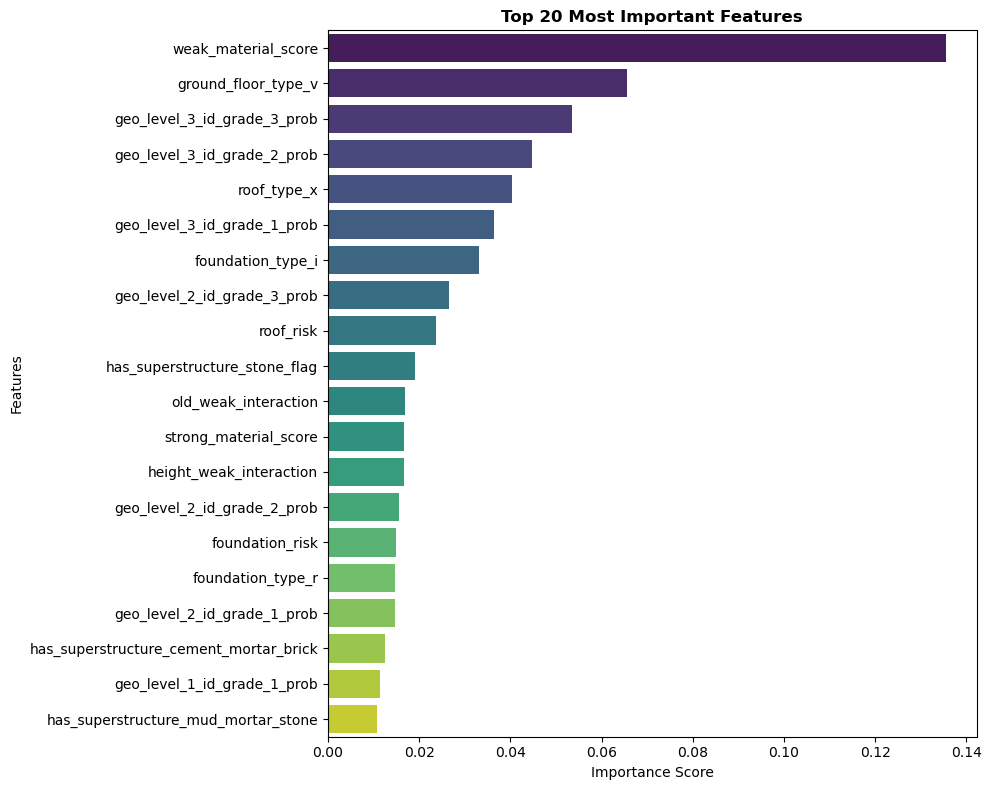

Top 5 Impactful Features:
                        Feature  Importance
52          weak_material_score    0.135441
25          ground_floor_type_v    0.065587
71  geo_level_3_id_grade_3_prob    0.053584
70  geo_level_3_id_grade_2_prob    0.044744
23                  roof_type_x    0.040336


In [66]:
# feature importance from your trained model
model = XGBClassifier(subsample = 0.7,  n_estimators= 1000, max_depth= 10, reg_lambda = 0.001, reg_alpha = 0.001, min_child_weight = 5,
                              tree_method = 'hist', learning_rate =0.01, gamma = 0, colsample_bytree = 0.7) 

# 2. THE MISSING STEP: Train the model
model.fit(X_train, y_train) 

importances = model.feature_importances_
feature_names = X_train.columns # or X_all.columns

# 2. Create a DataFrame for easy plotting
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 3. Plot the Top 20 Features
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20), palette='viridis')

plt.title('Top 20 Most Important Features', fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# Print the top 5 for report
print("Top 5 Impactful Features:")
print(feature_importance_df.head(5))


Feature importance analysis reveals that structural vulnerability (weak_material_score) and granular geographic risk (geo_level_3 probabilities) are the primary drivers of the model's predictions. The high weight assigned to target-encoded geographic probabilities suggests that local seismic intensity and neighborhood-level construction trends are more predictive than broad regional data. Additionally, the significance of ground_floor_type_v highlights the model's ability to distinguish between modern resilient structures and traditional, higher-risk buildings.

In [60]:
from sklearn.metrics import confusion_matrix

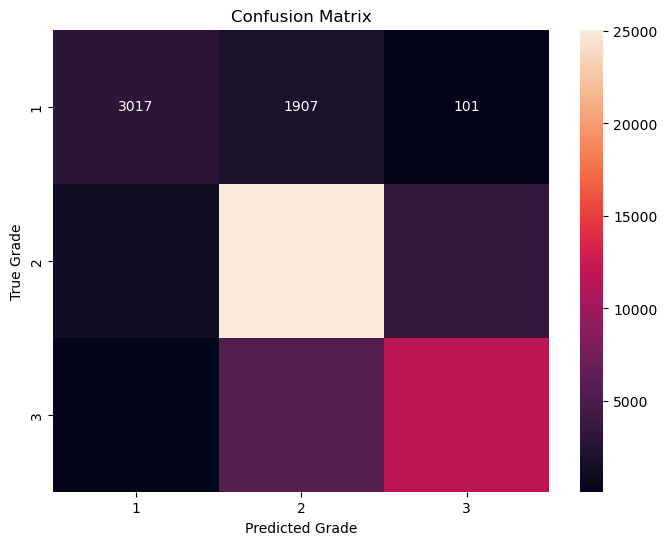

In [64]:
# Confusion Matrix
model_xgb = XGBClassifier(subsample = 0.7,  n_estimators= 1000, max_depth= 10, reg_lambda = 0.001, reg_alpha = 0.001, min_child_weight = 5,
                              tree_method = 'hist', learning_rate =0.01, gamma = 0, colsample_bytree = 0.7)

model_xgb.fit(X_train, y_train)
y_pred_x = model_xgb.predict(X_test)
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_x)
sns.heatmap(cm, annot=True, fmt='d', 
            xticklabels=[1, 2, 3], yticklabels=[1, 2, 3])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Grade')
plt.ylabel('True Grade')
plt.show()

# Task 3: Suggestions to Seismologists

* Since weak_material_score is the top predictor, focus immediate mitigation efforts on buildings using mud-mortar and non-engineered stone. Replacing or reinforcing these specific binders is the most effective way to reduce structural failure.
*  Use the high importance of geo_level_3_id probabilities to move beyond general regional risk assessments. Seismologists should adopt "micro-zoning" at the village or neighborhood level to identify specific high-risk clusters for targeted evacuations or structural audits
* : Given that Type V ground floors correlate with lower damage, advocate for the standardisation of reinforced concrete or modern flooring in new builds. This single structural change appears to be a "tipping point" feature that significantly increases building resilienc
* ": Leverage the model's focus on Grade 2 and 3 probabilities to create predictive heatmaps. These should be used to pre-position emergency response resources in areas where the model predicts the highest likelihood of severe damageldings.

# REPORT ON CHALLENGES FACED

**1. Challenges Faced:**
   - **High Cardinality in Geo-Locations:**
     * *Challenge:* `geo_level_2_id` and `geo_level_3_id` have thousands of unique values. Standard One-Hot encoding would create a dataset too wide to process efficiently.
     * *Technique:* We kept these IDs as numeric features for the XGBoost model. Tree-based models can handle high-cardinality integers effectively by splitting the feature space, avoiding the need for massive dimensionality expansion.
   
   - **Class Imbalance:**
     * *Challenge:* Damage Grade 2 represents the majority of the data, causing models to be biased toward predicting Grade 2.
     * *Technique:* Used 'Stratified Split' for validation to ensure all grades were represented. We also prioritized the **Micro-F1 Score** metric, which gives a better representation of performance across unbalanced classes than simple accuracy.

   - **Multicollinearity:**
     * *Challenge:* `count_floors_pre_eq` and `height_percentage` provided redundant information.
     * *Technique:* The XGBoost algorithm naturally handles this by selecting the stronger splitter at each node, so manual feature dropping was not strictly necessary, preserving data integrity.
